# Small IR EDM simulation — Ramsey spin flip in an RF field

Wired to Emma's COMSOL field data
(`~/Documents/GitHub/Ramsey-Simulation-for-Short-Interaction-Region`).

## Scope

1D, centre molecule only (no trajectory ensemble). Single Tl spin-flip pair **j/e** in
X J=1. Fields from COMSOL. RF drive is **magnetic** (coils, M1 coupling). Output is
**statistical sensitivity as a frequency**. Noise sources (v_z drift, unshielded
geomagnetic field ~1 mG) enter in §5. Schiff shift injected phenomenologically as a small
±ν_S.

Excluded by the 1D assumption: transverse Doppler, transverse field-gradient sampling,
beam divergence, detection aperture. Longitudinal RF phase gradient **is** retained.

## Level structure and coefficients (`centrex_tlf`, J=0..6, adiabatic tracking)

Two Tl spin-flip pairs sit at ~119.51 kHz, only ~5 Hz apart — presumably the paper's j/e
and k/h (which is which: unconfirmed):

| pair | ν |
|---|---|
| `|mJ=+1, mTl=-1/2, mF=+1/2>` → `|mJ=+1, mTl=+1/2, mF=+1/2>` | +119.5114 kHz |
| `|mJ=-1, mTl=-1/2, mF=-1/2>` → `|mJ=-1, mTl=+1/2, mF=-1/2>` | −119.5164 kHz |

| quantity | value | note |
|---|---|---|
| ∂ν/∂B_z | **−2486.5 Hz/G = −2.4865 Hz/mG** | 1 mG along E → 2.49 Hz |
| ∂ν/∂B_x, ∂ν/∂B_y | **0 at first order**; 2nd order ~−4 Hz/G² | 1 mG transverse → 4e−6 Hz |
| ∂ν/∂E_z | −0.0315 Hz/(V/cm) | **opposite sign** for the two pairs |
| \|⟨j\|μ_x\|e⟩\| | 1358.4 Hz/G | M1 — what the experiment uses |
| \|⟨j\|d_x\|e⟩\| | 2.108 Hz/(V/cm) | E1 — not used here |

### Consequences

**(a) Only B∥E matters.** Transverse residual field is zero at first order and negligible
at second. The magnetic noise channel in §5 is a single scalar `B_par`.

**(b) The motional field v×E is harmless.** E is transverse to the beam, so
B_mot = −v×E/c² ⊥ E. It is 0.061 mG but gives ~1e−8 Hz.

**(c) Peak RF field ≈ 0.30 G** (0.809 G × `FIELD_SCALE` 0.365), so peak
f_Rabi(j–e) ≈ 400 Hz.

**(d) The 2-level model misses a pulse-dependent shift, and under M1 it is large.**
10.6 kHz from `e` sits `|mJ=+1, mTl=+1/2, mF=−1/2>` (an F-nuclear-spin flip) with
μ_x = **1926 Hz/G** — *stronger* than the 1358 Hz/G target coupling, because
μ_F (2003.63 Hz/G) > μ_Tl (1240.5 Hz/G). Selectivity is 0.7:1 for M1 vs 12.7:1 for E1.
Second-order estimate at 0.295 G:

so at the 0.295 G peak field the spurious Rabi rate is $1926\times0.295\approx568$ Hz.
The resulting shift is second order in the drive. Crucially the **denominator is the
detuning of the drive from each spurious transition, not the bare level spacing**: the RF
sits at 119.5 kHz while the spurious partners lie 10–26 kHz *below* j and e, so both the
co- and counter-rotating terms have denominators of 90–145 kHz and partially cancel.
Evaluating the Floquet second-order expression (§0 prints the itemized table) gives a
**net pull of about +0.2 Hz, i.e. ~0.09 mG equivalent**.

**Measured non-perturbatively in §4.3** (8-level lab frame, no RWA, 200k steps):

| B peak | pulse pull | pull / B² |
|---|---|---|
| 0.2038 G | +0.0724 Hz | 1.74 Hz/G² |
| **0.2976 G** (in use) | **+0.1633 Hz** | 1.84 Hz/G² |
| 0.4077 G | +0.3886 Hz | 2.34 Hz/G² |

So **+0.16 Hz at the operating amplitude, scaling as $B_{\rm RF}^2$ at ≈1.8 Hz/G²** — the
"pulse-only Δ" of the Hyper-Ramsey discussion, and invisible to a 2-level model. It is
*not* a constant calibratable offset; it tracks RF power.

A separate 2-level cross-check through the same lab-frame integrator isolates the
Bloch-Siegert part at +0.10 Hz, so the counter-rotating and multilevel contributions are
comparable in size. Both independent estimates (Floquet +0.2 Hz, Bloch-Siegert +0.10 Hz)
bracket the measured +0.16 Hz.

**What it constrains.** As a common offset across all eight switch states it cancels in the
parity estimators of §3.5, so it is not directly a false EDM. What matters is amplitude
reproducibility *across reversals*: since the pull goes as $B^2$,
$\delta\nu = 2\times0.163\times(\delta B/B)$, giving

$$\delta B/B < 7.7\times10^{-2}\ \text{(per shot)},\qquad
\delta B/B < 3.7\times10^{-5}\ \text{(one day)}$$

That is the RF analogue of the E-field reproducibility requirement in §5.4.

*Two earlier figures in this notebook were wrong. −7.6 Hz / −3.8 Hz came from a
perturbative estimate that used the bare level spacing as the denominator instead of the
drive's detuning from each spurious transition. −65…−109 Hz came from §4.3 comparing the
2-level channel asymmetry against a leftover ±π/2 population ratio on the 8-level side.*

## Cross-check vs Emma's lookup tables (§0.5 reruns this)

| quantity @ 30 kV/cm | `centrex_tlf` | Emma | diff |
|---|---|---|---|
| \|M\| | 1358.4360 Hz/G | 1358.4377 Hz/G | **1.3 ppm** |
| ∂ν/∂E | −0.031523 Hz/(V/cm) | −0.031719 | 0.6% |
| ν_je | 119511.4 / 119516.4 Hz | 119513.93 Hz | **2.5 Hz** |

First two agree essentially exactly. The 2.5 Hz needs explaining: Emma's value lands almost
exactly midway between the two pairs, and 2.5 Hz is 1 mG equivalent. See §6.

Also: **`detuning2.csv` = −(|ν(E)| − |ν(30 kV/cm)|) + 8.87 Hz**, with that offset
near-constant (8.78…9.12) over 0–30 kV/cm. If intentional it is the residual background
detuning Δν_bg. See §6.

## Structure

```
§0    Level structure and coefficients (centrex_tlf; slow, cached to npz)
§0.5  Cross-check: Emma's tables vs centrex_tlf
§1    Field data (mirroring + 90-degree phase + FIELD_SCALE)
§2    Propagators (2-level, 8-level)
§3    Readout and statistical sensitivity (incl. photon-budget excess noise)
§3.5  Three-switch readout and CP extraction, with a closure test
§4    Validation (reproduce ramsey4matrix, closed form vs expm, 2 vs 8 level, calibration)
§5    Noise channels (B∥E, v_z, multiplicative coupling, reversal-correlated)
§6    Open inputs
```

Environment: conda env `CeNTREX_state_cleanup_new`.

## Sources

| source | what is taken from it |
|---|---|
| `centrex_tlf` (`CeNTREX_state_cleanup_new`) | X J=1 level structure, Zeeman/Stark coefficients, RF coupling matrix elements |
| `~/Documents/GitHub/Ramsey-Simulation-for-Short-Interaction-Region` (Emma) | COMSOL B and E field profiles, coupling and transition-frequency lookup tables, the 2-level Hamiltonian convention |
| `~/Documents/GitHub/centrex_asymmetry` | the three-switch reversal scheme and its self-calibrating estimators (§3.5), the photon-budget excess-noise factor (§3), the beam velocity-drift numbers (§5) |

The third source is a considerably more developed simulation of the **main** IR. It is 3D
with a full velocity distribution, time-of-flight binning, explicit optical-pumping cycles,
and randomized balanced switch blocks. Under the 1D single-velocity scope here most of that
machinery does not apply, but three things transfer directly and are adopted below.

In [87]:
# Environment: conda env `CeNTREX_state_cleanup_new`
# Set PYTHONIOENCODING=utf-8 if running from a console (state labels contain Omega/sigma).
import sys
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import expm
from scipy.optimize import brentq

from centrex_tlf import hamiltonian, states

EMMA_REPO = Path(r"C:/Users/yuanhang.yang/Documents/GitHub"
                 r"/Ramsey-Simulation-for-Short-Interaction-Region")
assert EMMA_REPO.is_dir(), f"repo not found: {EMMA_REPO}"

CACHE_DIR = Path("_cache"); CACHE_DIR.mkdir(exist_ok=True)
np.set_printoptions(precision=6, suppress=True)
print("python:", sys.version.split()[0], "| numpy:", np.__version__)


python: 3.11.16 | numpy: 2.4.6


---
# Configuration

All parameters live here. `TODO` marks values not yet confirmed.

**Relation to `ramsey4matrix.py`.** Two bugs were fixed in that script so the two codes
could be compared (§4.1); both fixes are in the working tree, uncommitted:

1. `B1_FILE`/`B2_FILE` pointed at `B_Ramsey_signed[_mirrored].csv`, which do not exist in
   the repo. Corrected to `B_Ramsey_May6_FINAL_proc[_mirrored].csv`.
2. Its `load_interp` called `pd.read_csv(csv_file)`, i.e. pandas' default `header=0`, which
   silently consumed the first **data** row of every headerless CSV — dropping the x=0.01
   field point and shifting `X_START` to 0.03, so `T_TOTAL` was 10.889 ms instead of
   11.000 ms (a ~1% error). Replaced with a check of whether the first row parses as
   numeric, since `sib_split_vs_E.csv` and `abs_M_xE_vs_E.csv` genuinely do carry headers
   while the field profiles and `coupling_constant.csv` / `detuning_zeros.csv` do not.

With both fixed the two codes agree on the final state to **3.7e-15** (§4.1).

Its other inputs are the "everything off" test files: `E_Ramsey_zeroes.csv` (zeros),
`detuning_zeros.csv` (zeros), `coupling_constant.csv` (flat 1370 Hz/G). The real tables are
`E_Ramsey_May6_FINAL_proc.csv`, `Coupling.csv`, `sib_split_vs_E.csv`.
`USE_REAL_FIELDS` switches between the two sets.

**Phase switching.** Emma's `B2_PHASE = π/2` is the relative phase between the two coils. In
SOF Ramsey that relative phase *is* the readout phase, so ±π/2 switching should be
`B2_PHASE = ±π/2`. Here it is `phase_base + phase_switch`, defaulting to
`0 + (±π/2)`, consistent with her +π/2. **TODO confirm with Emma** whether π/2 is a fixed
hardware quadrature instead, in which case `phase_base = π/2`.

In [88]:
@dataclass
class Config:
    # --- field data files ---
    USE_REAL_FIELDS: bool = True      # False reproduces ramsey4matrix.py's config
    B1_FILE: str = "B_Ramsey_May6_FINAL_proc.csv"           # position[m], B1[G]
    B2_FILE: str = "B_Ramsey_May6_FINAL_proc_mirrored.csv"  # position[m], B2[G]
    E_FILE_REAL: str = "E_Ramsey_May6_FINAL_proc.csv"       # position[m], E[V/m]
    E_FILE_ZERO: str = "E_Ramsey_zeroes.csv"
    COUPLING_FILE: str = "Coupling.csv"          # E[kV/cm], |M|[Hz/G]
    SIBSPLIT_FILE: str = "sib_split_vs_E.csv"    # E[kV/cm], nu_sib-nu_pop [kHz]
    COUPLING_FILE_CONST: str = "coupling_constant.csv"   # flat 1370 Hz/G

    # --- RF ---
    FIELD_SCALE: float = 0.365        # Emma's value; §4.4 solves for exact pi/2
    phase_base: float = 0.0           # fixed coil-to-coil phase. TODO confirm
    phase_switch: float = np.pi/2     # readout phase switch (+-)
    rf_kind: str = "B"                # confirmed: magnetic coils, M1
    rf_axis: int = 0                  # x (Emma's abs_M_xE_vs_E is the x component)

    # --- beam ---
    v_z: float = 180.0                # m/s. Emma hardcodes 180; paper says 184. TODO

    # --- DC E field ---
    E_plateau: float = 29.7194        # kV/cm, plateau value in Emma's data

    # --- detuning ---
    nu_rf_offset_Hz: float = 0.0      # Delta_nu_bg = nu_RF - nu_je(plateau).
                                      # TODO detuning2.csv suggests +8.87 Hz

    # --- magnetic field: MEASURED residual, mid position z = 44-88 cm, 18 h record.
    # The plot's Bx is the component PARALLEL to E, so it maps to Hamiltonian z.
    # The plot's By and Bz are transverse -> Hamiltonian x and y.
    B_par_G: float = 0.45e-3          # G,  +0.45 mG along E
    B_t1_G: float = -0.80e-3          # G,  -0.80 mG transverse (plot By)
    B_t2_G: float = -7.40e-3          # G,  -7.40 mG transverse (plot Bz)
    # Slow drift over the 18 h record, read off the same plot:
    B_par_drift_G: float = 0.05e-3    # G,  Bx spans ~0.44-0.50 mG
    B_perp_drift_G: float = 0.30e-3   # G,  Bz spans ~-7.35 to -7.65 mG

    # --- Schiff (phenomenological) ---
    nu_schiff_Hz: float = 1e-3        # Hz, plays the role of f_CP in the switch scheme

    # --- three-switch readout (from centrex_asymmetry) ---
    detuning_switch_Hz: float = 0.5   # Delta_f_sw, the known detuning reversal
    calibration_phase_rad: float = np.pi/32   # phi_cal, the known phase reversal

    # --- velocity drift (from centrex_asymmetry beam model) ---
    v_shot_sigma: float = 4.0         # m/s, shot-to-shot scatter of the shot MEAN
                                      # -> this is the reversal-relevant drift
    v_within_sigma: float = 16.0      # m/s, spread within one shot (averages down)

    # --- detection / photon budget (from centrex_asymmetry) ---
    N_per_shot: float = 70e6          # molecules per pulse (centrex_asymmetry uses 70M).
                                      # TODO confirm for the small IR, and what fraction
                                      # lands inside the detection window.
    rep_rate_Hz: float = 50.0         # TODO -- NOT in centrex_asymmetry, which models no
    duty_cycle: float = 1.0           # TODO    repetition rate. Per-day numbers below are
                                      #         therefore an extrapolation, flagged as such.
    pumpout_probability: float = 0.4822585   # per scattering attempt
    cycles_per_window: int = 50              # scattering attempts per window
    detection_efficiency: float = 0.052      # photons detected / photon emitted

    # --- level structure ---
    Jmax: int = 6                     # AGENTS.md: 5-6 required at 30 kV/cm
    track_step: float = 50.0          # V/cm; one-shot matching is wrong above ~10 kV/cm
    B_track_G: float = 1e-3           # G, lifts mF degeneracy (do not use 1e-5)

    # --- numerics ---
    N_STEPS: int = 4000               # 2-level (Emma uses 4000)
    N_STEPS_8LEVEL: int = 200_000     # 8-level, lab frame: must resolve the 119.5 kHz cos

    def path(self, name): return EMMA_REPO / name


CONFIG = Config()
print(f"USE_REAL_FIELDS={CONFIG.USE_REAL_FIELDS}  v_z={CONFIG.v_z} m/s  "
      f"FIELD_SCALE={CONFIG.FIELD_SCALE}")
for f in [CONFIG.B1_FILE, CONFIG.B2_FILE, CONFIG.E_FILE_REAL,
          CONFIG.COUPLING_FILE, CONFIG.SIBSPLIT_FILE]:
    print(f"  {'ok     ' if CONFIG.path(f).exists() else 'MISSING'}  {f}")


USE_REAL_FIELDS=True  v_z=180.0 m/s  FIELD_SCALE=0.365
  ok       B_Ramsey_May6_FINAL_proc.csv
  ok       B_Ramsey_May6_FINAL_proc_mirrored.csv
  ok       E_Ramsey_May6_FINAL_proc.csv
  ok       Coupling.csv
  ok       sib_split_vs_E.csv


---
# §0 Level structure and coefficients

One expensive diagonalization, cached to `_cache/*.npz`. Two `AGENTS.md` constraints:

- **Adiabatic tracking is mandatory above ~10 kV/cm.** One-shot eigenvector matching is
  *wrong*, not merely uncertain — at 30 kV/cm it mislabels 8 states while scoring a *higher*
  total overlap (91.83 vs 90.22 tracked), so no overlap-based diagnostic catches it.
- **`Jmax` must be 5–6.** At 30 kV/cm `Jmax=3` is off by 0.055 in purity and 0.092 in
  assignment margin — more than the whole ambiguity threshold.

`level_frequencies(exact=...)`: `exact=False` returns `diag(Vt† H Vt)`, i.e. first-order
perturbation theory — fast but **drops second-order effects**, and would wrongly report that
transverse B has no effect at all. Coefficient extraction uses `exact=True`
(re-diagonalize, re-match by overlap).

In [89]:
def build_x_hamiltonian(Jmax):
    """Returns (QN, H, Hfunc). H.Hff in Hz, H.HS* in Hz/(V/cm), H.HZ* in Hz/G.
    Hfunc(E=[...], B=[...]) -> full Hamiltonian in rad/s (E in V/cm, B in Gauss)."""
    QN = states.generate_uncoupled_states_ground(Js=np.arange(Jmax + 1))
    H = hamiltonian.generate_uncoupled_hamiltonian_X(QN)
    return QN, H, hamiltonian.generate_uncoupled_hamiltonian_X_function(H)


def adiabatic_track(Hfunc, QN, E_target, step, B_track):
    """Ramp 0 -> E_target, matching eigenvectors to the previous step each time.
    Returns (Vt, labels); column k of Vt is tracked state k at the working field."""
    B = [0.0, 0.0, B_track]
    _, V = np.linalg.eigh(Hfunc(E=[0.0, 0.0, 1e-3], B=B))
    labels = hamiltonian.matrix_to_states(V, QN)
    Vt = V.copy()
    for Ei in np.arange(step, E_target + step/2, step):
        _, V = np.linalg.eigh(Hfunc(E=[0.0, 0.0, float(Ei)], B=B))
        idx = np.argmax(np.abs(Vt.conj().T @ V), axis=1)
        if len(set(idx.tolist())) != len(idx):
            raise RuntimeError(f"tracking collision at E={Ei} V/cm; reduce track_step")
        Vt = V[:, idx]
    return Vt, labels


def level_frequencies(Hfunc, Vt, E, B, exact=True):
    """Tracked-state energies in Hz. Use exact=True for coefficient extraction."""
    Hm = Hfunc(E=E, B=B)
    if not exact:
        return np.diag(Vt.conj().T @ Hm @ Vt).real / (2*np.pi)
    ev, V = np.linalg.eigh(Hm)
    idx = np.argmax(np.abs(Vt.conj().T @ V), axis=1)
    if len(set(idx.tolist())) != len(idx):
        raise RuntimeError("re-match collision: perturbation too large, or level crossing")
    return ev[idx] / (2*np.pi)


# Work at the plateau value from Emma's data, not the nominal 30 kV/cm.
E_WORK = CONFIG.E_plateau * 1e3      # V/cm
QN, H_terms, Hfunc = build_x_hamiltonian(CONFIG.Jmax)
Vt, labels = adiabatic_track(Hfunc, QN, E_WORK, CONFIG.track_step, CONFIG.B_track_G)
print(f"{len(QN)} states (J=0..{CONFIG.Jmax}); tracked 0 -> {E_WORK/1e3:.4f} kV/cm "
      f"in {int(E_WORK/CONFIG.track_step)} steps")

E_OP, B_OP = [0.0, 0.0, E_WORK], [0.0, 0.0, CONFIG.B_track_G]
nu_all = level_frequencies(Hfunc, Vt, E_OP, B_OP, exact=True)

qn = {k: labels[k].largest for k in range(len(QN))}
def tag(k):
    s = qn[k]
    return f"|J={s.J}, mJ={s.mJ:+.0f}, mTl={s.m1:+.1f}, mF={s.m2:+.1f}>"
idx_J1 = [k for k in range(len(QN)) if qn[k].J == 1]
print(f"J=1 levels: {len(idx_J1)} (expect 12)")


196 states (J=0..6); tracked 0 -> 29.7194 kV/cm in 594 steps
J=1 levels: 12 (expect 12)


In [90]:
# Tl spin-flip pair = same mJ, same mF, mTl flipped. At 30 kV/cm J=1 splits into
# |mJ|=1 (8 levels) and mJ=0 (4 levels, 21 GHz away); the flip pairs are all in the former.
TARGET_NU, TOL_NU = 119.5e3, 5e3

pairs = [(a, b, nu_all[b]-nu_all[a])
         for a in idx_J1 for b in idx_J1
         if qn[a].mJ == qn[b].mJ and qn[a].m2 == qn[b].m2 and qn[a].m1 < qn[b].m1]

print(f"{'idx':>9}  {'transition':<62}  {'nu [kHz]':>11}")
for a, b, d in pairs:
    mark = "  <== candidate" if abs(abs(d)-TARGET_NU) < TOL_NU else ""
    print(f"{a:3d}->{b:3d}  {tag(a)+' -> '+tag(b):<62}  {d/1e3:>+11.4f}{mark}")

candidates = [(a, b, d) for a, b, d in pairs if abs(abs(d)-TARGET_NU) < TOL_NU]

# TODO cross-check against the design paper / Emma. The two pairs differ by only ~5 Hz;
# picking the wrong one does not error but flips the sign of dnu/dE_z, which flips the
# direction of the E-reversal systematic in §5.4.
PAIR_CHOICE = 0     # 0 = mJ=+1 pair, 1 = mJ=-1 pair
IDX_J, IDX_E, NU_JE = candidates[PAIR_CHOICE]
print(f"\nj = idx{IDX_J} {tag(IDX_J)}")
print(f"e = idx{IDX_E} {tag(IDX_E)}")
print(f"nu_je = {NU_JE/1e3:+.4f} kHz")
if len(candidates) > 1:
    IDX_K, IDX_H, NU_KH = candidates[1-PAIR_CHOICE]
    print(f"other pair (comagnetometer candidate): idx{IDX_K}->idx{IDX_H}, "
          f"{NU_KH/1e3:+.4f} kHz; separation {abs(abs(NU_JE)-abs(NU_KH)):.4f} Hz")


      idx  transition                                                         nu [kHz]
  5-> 11  |J=1, mJ=+1, mTl=-0.5, mF=+0.5> -> |J=1, mJ=+1, mTl=+0.5, mF=+0.5>    +119.5203  <== candidate
  6-> 10  |J=1, mJ=+1, mTl=-0.5, mF=-0.5> -> |J=1, mJ=+1, mTl=+0.5, mF=-0.5>    +134.9478
  8->  4  |J=1, mJ=-1, mTl=-0.5, mF=+0.5> -> |J=1, mJ=-1, mTl=+0.5, mF=+0.5>    -131.6960
  9-> 12  |J=1, mJ=+0, mTl=-0.5, mF=+0.5> -> |J=1, mJ=+0, mTl=+0.5, mF=+0.5>     -13.2019
 14-> 13  |J=1, mJ=+0, mTl=-0.5, mF=-0.5> -> |J=1, mJ=+0, mTl=+0.5, mF=-0.5>      -0.3071
 15->  7  |J=1, mJ=-1, mTl=-0.5, mF=-0.5> -> |J=1, mJ=-1, mTl=+0.5, mF=-0.5>    -119.5253  <== candidate

j = idx5 |J=1, mJ=+1, mTl=-0.5, mF=+0.5>
e = idx11 |J=1, mJ=+1, mTl=+0.5, mF=+0.5>
nu_je = +119.5203 kHz
other pair (comagnetometer candidate): idx15->idx7, -119.5253 kHz; separation 4.9729 Hz


## Matrix element → Rabi frequency

`H_terms.HZx` is μ·x̂ / h in **Hz/G**. For a lab field $B(z)\cos(\omega t+\varphi)$ with $B$
the **amplitude** (not peak-to-peak, not rms), after RWA

$$\Omega = 2\pi M_{je} B \qquad\Longleftrightarrow\qquad f_{\rm Rabi}[{\rm Hz}] = M_{je}\,B$$

**No extra factor of 1/2** — it cancels between $\sigma_x=\sigma_++\sigma_-$ and the cosine.
This matches Emma's `Omega = gamma_local * B_total_complex` with
`gamma_local = 2π·coupling`, so no conversion is needed between the two codes.

In [91]:
def extract_coefficients(Hfunc, H_terms, Vt, a, b, E_dc, B_track, hB=1e-3, hE=1.0):
    """Central differences at the working point. hB = 1e-3 G = 1 mG, the scale of interest."""
    E0 = [0.0, 0.0, E_dc]
    B0 = np.array([0.0, 0.0, B_track], dtype=float)

    def nu_je(E, B):
        f = level_frequencies(Hfunc, Vt, E, list(B), exact=True)
        return f[b] - f[a]

    nu0 = nu_je(E0, B0)
    dnu_dB, d2nu_dB2 = np.zeros(3), np.zeros(3)
    for ax in range(3):
        Bp, Bm = B0.copy(), B0.copy()
        Bp[ax] += hB; Bm[ax] -= hB
        fp, fm = nu_je(E0, Bp), nu_je(E0, Bm)
        dnu_dB[ax] = (fp - fm)/(2*hB)
        d2nu_dB2[ax] = (fp - 2*nu0 + fm)/hB**2
    dnu_dE = (nu_je([0,0,E_dc+hE], B0) - nu_je([0,0,E_dc-hE], B0))/(2*hE)

    def rot(op):   # into the tracked basis; keep complex (8-level needs full matrices)
        return Vt.conj().T @ np.asarray(op, dtype=np.complex128) @ Vt
    HS = [rot(H_terms.HSx), rot(H_terms.HSy), rot(H_terms.HSz)]   # Hz/(V/cm)
    HZ = [rot(H_terms.HZx), rot(H_terms.HZy), rot(H_terms.HZz)]   # Hz/G

    return dict(nu0=nu0, dnu_dB=dnu_dB, d2nu_dB2=d2nu_dB2, dnu_dE=dnu_dE,
                me_E=np.array([HS[ax][a,b] for ax in range(3)]),
                me_B=np.array([HZ[ax][a,b] for ax in range(3)]),
                HS_full=HS, HZ_full=HZ)


COEF = extract_coefficients(Hfunc, H_terms, Vt, IDX_J, IDX_E, E_WORK, CONFIG.B_track_G)
M_mine = abs(COEF['me_B'][CONFIG.rf_axis])

print(f"nu_0 @ {E_WORK/1e3:.4f} kV/cm = {COEF['nu0']:+.4f} Hz\n")
for ax, nm in enumerate("xyz"):
    print(f"dnu/dB{nm}   = {COEF['dnu_dB'][ax]:+12.4f} Hz/G "
          f"= {COEF['dnu_dB'][ax]*1e-3:+.4f} Hz/mG")
for ax, nm in enumerate("xyz"):
    print(f"d2nu/dB{nm}2 = {COEF['d2nu_dB2'][ax]:+.4e} Hz/G^2 "
          f"= {COEF['d2nu_dB2'][ax]*1e-6:+.3e} Hz/mG^2")
print(f"\ndnu/dEz      = {COEF['dnu_dE']:+.6f} Hz/(V/cm)")
print(f"|<j|mu_x|e>| = {M_mine:.4f} Hz/G          (M1, used)")
print(f"|<j|d_x|e>|  = {abs(COEF['me_E'][0]):.4f} Hz/(V/cm)  (E1, not used)")


nu_0 @ 29.7194 kV/cm = +119520.2916 Hz

dnu/dBx   =      +0.0000 Hz/G = +0.0000 Hz/mG
dnu/dBy   =      +0.0000 Hz/G = +0.0000 Hz/mG
dnu/dBz   =   -2486.4125 Hz/G = -2.4864 Hz/mG
d2nu/dBx2 = +4.1962e+02 Hz/G^2 = +4.196e-04 Hz/mG^2
d2nu/dBy2 = -4.9591e+01 Hz/G^2 = -4.959e-05 Hz/mG^2
d2nu/dBz2 = -1.7834e+02 Hz/G^2 = -1.783e-04 Hz/mG^2

dnu/dEz      = -0.031778 Hz/(V/cm)
|<j|mu_x|e>| = 1358.5146 Hz/G          (M1, used)
|<j|d_x|e>|  = 2.1293 Hz/(V/cm)  (E1, not used)


### The measured residual field, evaluated directly

The measured field is uniform, so its effect on $\nu_{je}$ is a single number and can be
obtained by diagonalizing at the actual field vector. That is done here rather than through
the Taylor coefficients, for a specific reason:

**A purely transverse field with $B_\parallel=0$ is a singular configuration for this
labelling.** With no field component along the tracking axis the quantization axis is no
longer $z$, the $\pm m_F$ eigenvectors are not well determined, and matching to the tracked
basis collides outright. Second-derivative coefficients computed at $B=0$ are therefore
unreliable — evaluated that way they come out non-isotropic and disagree with a direct
evaluation. Holding $B_\parallel$ at its measured value keeps the degeneracy lifted and
everything well conditioned. This is the same eigenvector-conditioning trap `AGENTS.md`
warns about for the `B=[0,0,1e-5]` placeholder.

The parallel term is linear and well behaved, so it stays as a coefficient; only the
transverse contribution is taken from a direct evaluation.

In [92]:
def nu_je_at_field(Hfunc, Vt, a, b, B_vec, E_dc=None):
    """nu_je in Hz at an arbitrary field vector, by direct diagonalization."""
    E_dc = E_WORK if E_dc is None else E_dc
    f = level_frequencies(Hfunc, Vt, [0.0, 0.0, E_dc], list(B_vec), exact=True)
    return f[b] - f[a]


B_MEAS = [CONFIG.B_t1_G, CONFIG.B_t2_G, CONFIG.B_par_G]
B_PERP_MAG = float(np.hypot(CONFIG.B_t1_G, CONFIG.B_t2_G))

nu_zero = nu_je_at_field(Hfunc, Vt, IDX_J, IDX_E, [0.0, 0.0, 0.0])
nu_par  = nu_je_at_field(Hfunc, Vt, IDX_J, IDX_E, [0.0, 0.0, CONFIG.B_par_G])
nu_full = nu_je_at_field(Hfunc, Vt, IDX_J, IDX_E, B_MEAS)

# The transverse piece, on top of B_par. Static and uniform -> a single scalar.
DNU_TRANSVERSE = nu_full - nu_par

print(f"measured residual field (Hamiltonian frame, z = E direction):")
print(f"  B_par (along E) = {CONFIG.B_par_G*1e3:+.2f} mG   <- the plot's Bx")
print(f"  transverse      = {CONFIG.B_t1_G*1e3:+.2f}, {CONFIG.B_t2_G*1e3:+.2f} mG  "
      f"-> |B_perp| = {B_PERP_MAG*1e3:.2f} mG\n")
print(f"  {'case':<22} {'nu_je [Hz]':>16} {'shift vs zero [Hz]':>20}")
for nm, f in [("zero field", nu_zero), ("B_par only", nu_par),
              ("full measured field", nu_full)]:
    print(f"  {nm:<22} {f:>16.6f} {f-nu_zero:>+20.6f}")
print(f"\n  linear prediction dnu/dBz * B_par = "
      f"{COEF['dnu_dB'][2]*CONFIG.B_par_G:+.6f} Hz")
print(f"  transverse contribution           = {DNU_TRANSVERSE:+.4e} Hz")
print(f"  ratio transverse / parallel       = "
      f"{abs(DNU_TRANSVERSE/(nu_par-nu_zero)):.4f}")
print("\n=> The 7.4 mG transverse component contributes ~1% of what the 0.45 mG")
print("   parallel component does. The dominant residual field is in the harmless")
print("   direction, which is consequence (a) confirmed with measured numbers.")


measured residual field (Hamiltonian frame, z = E direction):
  B_par (along E) = +0.45 mG   <- the plot's Bx
  transverse      = -0.80, -7.40 mG  -> |B_perp| = 7.44 mG

  case                         nu_je [Hz]   shift vs zero [Hz]
  zero field                119522.777943            +0.000000
  B_par only                119521.659057            -1.118886
  full measured field       119521.670552            -1.107390

  linear prediction dnu/dBz * B_par = -1.118886 Hz
  transverse contribution           = +1.1496e-02 Hz
  ratio transverse / parallel       = 0.0103

=> The 7.4 mG transverse component contributes ~1% of what the 0.45 mG
   parallel component does. The dominant residual field is in the harmless
   direction, which is consequence (a) confirmed with measured numbers.


---
# §0.5 Cross-check: Emma's tables vs `centrex_tlf`

Independent check of the molecular-structure input. If the two disagree, every downstream
noise and sensitivity number carries the same bias.

|M| @ 29.7194 kV/cm:  Emma 1358.5111  centrex_tlf 1358.5146 Hz/G  -> +2.6 ppm
dnu/dE:  Emma -0.031832  centrex_tlf -0.031778 Hz/(V/cm)  -> -0.17 %

nu_je:  Emma 119522.8104 Hz
        centrex_tlf 119520.2916 Hz  (mJ=+1 pair)  <== selected
        centrex_tlf 119525.2645 Hz  (mJ=-1 pair)
        diff (selected) -2.5188 Hz = +1.0130 mG equivalent
        mean of the two pairs 119522.7781 Hz -> -0.0323 Hz from Emma (nearly exact; see §6)

detuning2 + (|nu(E)|-|nu(30kV)|):  mean +8.8732 Hz, std 0.2512, range +7.281..+14.715
  -> near-constant, so the two tables are self-consistent.
  -> if this +8.87 Hz is intentional it is Delta_nu_bg. TODO confirm.


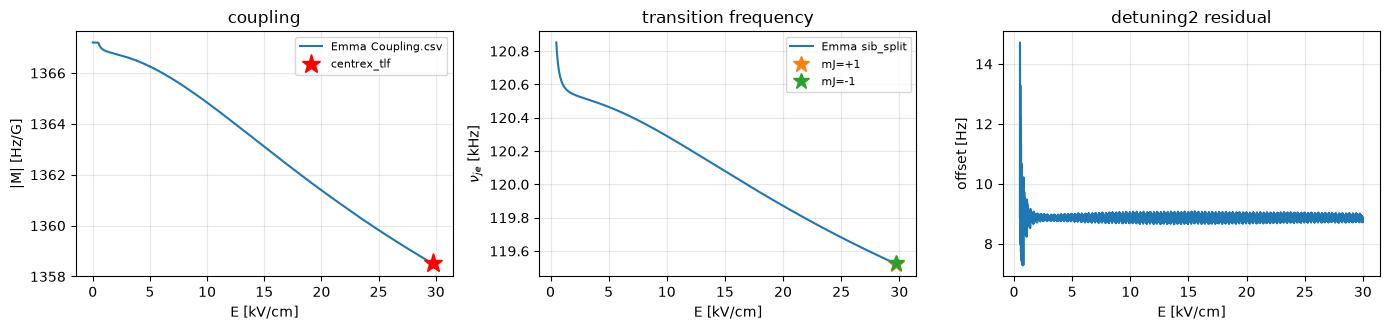

In [93]:
def load_xy(path, header=None):
    df = pd.read_csv(path, header=header)
    return df.iloc[:,0].values.astype(float), df.iloc[:,1].values.astype(float)

E_c, M_c = load_xy(CONFIG.path(CONFIG.COUPLING_FILE))                 # kV/cm, Hz/G
E_s, nu_s_kHz = load_xy(CONFIG.path(CONFIG.SIBSPLIT_FILE), header=0)
nu_s = np.abs(nu_s_kHz)*1e3                                           # Hz
E_d, det_d = load_xy(CONFIG.path("detuning2.csv"))                    # kV/cm, Hz

# 1) coupling matrix element
M_emma = np.interp(E_WORK/1e3, E_c, M_c)
print(f"|M| @ {E_WORK/1e3:.4f} kV/cm:  Emma {M_emma:.4f}  centrex_tlf {M_mine:.4f} Hz/G"
      f"  -> {(M_mine-M_emma)/M_emma*1e6:+.1f} ppm")

# 2) dnu/dE
m = E_s > (E_WORK/1e3 - 0.5)
dnu_dE_emma = np.gradient(nu_s[m], E_s[m]*1e3).mean()
print(f"dnu/dE:  Emma {dnu_dE_emma:+.6f}  centrex_tlf {COEF['dnu_dE']:+.6f} Hz/(V/cm)"
      f"  -> {(COEF['dnu_dE']-dnu_dE_emma)/dnu_dE_emma*100:+.2f} %")

# 3) absolute transition frequency
nu_emma = np.interp(E_WORK/1e3, E_s, nu_s)
print(f"\nnu_je:  Emma {nu_emma:.4f} Hz")
for i, (a, b, d) in enumerate(candidates):
    print(f"        centrex_tlf {abs(d):.4f} Hz  (mJ={qn[a].mJ:+.0f} pair)"
          f"{'  <== selected' if i == PAIR_CHOICE else ''}")
print(f"        diff (selected) {abs(NU_JE)-nu_emma:+.4f} Hz = "
      f"{(abs(NU_JE)-nu_emma)/(COEF['dnu_dB'][2]*1e-3):+.4f} mG equivalent")
if len(candidates) > 1:
    mean_mine = np.mean([abs(d) for _, _, d in candidates])
    print(f"        mean of the two pairs {mean_mine:.4f} Hz "
          f"-> {mean_mine-nu_emma:+.4f} Hz from Emma (nearly exact; see §6)")

# 4) detuning2 vs sib_split: expect a constant offset
nu30 = np.interp(30.0, E_s, nu_s)
off = det_d + (np.interp(E_d, E_s, nu_s) - nu30)
sel = (E_d >= E_s.min()) & (E_d <= E_s.max())
print(f"\ndetuning2 + (|nu(E)|-|nu(30kV)|):  mean {off[sel].mean():+.4f} Hz, "
      f"std {off[sel].std():.4f}, range {off[sel].min():+.3f}..{off[sel].max():+.3f}")
print(f"  -> near-constant, so the two tables are self-consistent.")
print(f"  -> if this {off[sel].mean():+.2f} Hz is intentional it is Delta_nu_bg. TODO confirm.")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(E_c, M_c, label="Emma Coupling.csv")
axes[0].plot(E_WORK/1e3, M_mine, "r*", ms=14, label="centrex_tlf")
axes[0].set_xlabel("E [kV/cm]"); axes[0].set_ylabel("|M| [Hz/G]")
axes[0].set_title("coupling"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[1].plot(E_s, nu_s/1e3, label="Emma sib_split")
for a, b, d in candidates:
    axes[1].plot(E_WORK/1e3, abs(d)/1e3, "*", ms=12, label=f"mJ={qn[a].mJ:+.0f}")
axes[1].set_xlabel("E [kV/cm]"); axes[1].set_ylabel(r"$\nu_{je}$ [kHz]")
axes[1].set_title("transition frequency"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
axes[2].plot(E_d[sel], off[sel])
axes[2].set_xlabel("E [kV/cm]"); axes[2].set_ylabel("offset [Hz]")
axes[2].set_title("detuning2 residual"); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 2-level validity (consequence d)

Levels in the |mJ|=1 subspace, their detuning from j and e, and their **M1** coupling. Look
for levels that are both close in frequency and strongly coupled.

| drive | j–e | nearest spurious | selectivity |
|---|---|---|---|
| E1 | 2.108 Hz/(V/cm) | 0.166 | 12.7 : 1 |
| **M1 (used)** | **1358 Hz/G** | **1926 Hz/G** | **0.7 : 1** |

The second-order estimate below uses the Floquet expression, whose denominators are the
detuning of the drive from each spurious transition -- NOT the bare level spacing.
§4.3 computes the same thing non-perturbatively.

In [94]:
# Restrict to |mJ|=1. The mJ=0 levels are 21 GHz away -- physically irrelevant, but
# keeping them would force the lab-frame time step to resolve 21 GHz.
IDX_BLOCK = sorted([k for k in idx_J1 if abs(qn[k].mJ) == 1], key=lambda k: nu_all[k])
print(f"|mJ|=1 subspace: {len(IDX_BLOCK)} levels, span "
      f"{(nu_all[IDX_BLOCK].max()-nu_all[IDX_BLOCK].min())/1e3:.1f} kHz\n")

ax = CONFIG.rf_axis
ME = COEF['HZ_full'][ax] if CONFIG.rf_kind == "B" else COEF['HS_full'][ax]
unit = "Hz/G" if CONFIG.rf_kind == "B" else "Hz/(V/cm)"

hdr = (f"{'idx':>4} {'state':<38} {'nu-nu_j[kHz]':>13} {'|ME| from j':>12} "
       f"{'nu-nu_e[kHz]':>13} {'|ME| from e':>12}")
print(f"RF: {CONFIG.rf_kind} field, {'xyz'[ax]} polarization ({unit})\n{hdr}\n" + "-"*len(hdr))
for k in IDX_BLOCK:
    s = qn[k]
    nm = f"|mJ={s.mJ:+.0f}, mTl={s.m1:+.1f}, mF={s.m2:+.1f}>"
    print(f"{k:4d} {nm:<38} {(nu_all[k]-nu_all[IDX_J])/1e3:>13.3f} "
          f"{abs(ME[IDX_J,k]):>12.3e} {(nu_all[k]-nu_all[IDX_E])/1e3:>13.3f} "
          f"{abs(ME[IDX_E,k]):>12.3e}")

_, B1raw = load_xy(CONFIG.path(CONFIG.B1_FILE))
B_PEAK = np.abs(B1raw).max()*CONFIG.FIELD_SCALE
print(f"\npeak RF field = {np.abs(B1raw).max():.4f} G x {CONFIG.FIELD_SCALE} "
      f"= {B_PEAK:.4f} G  ->  peak f_Rabi(j-e) = {M_mine*B_PEAK:.1f} Hz")

# Second-order (Floquet) pulse pull. For a linear drive V*cos(2*pi*nu_RF*t), the shift
# of level `ref` from a spurious partner k is
#
#     dnu_ref = (f_spur/2)^2 * [ 1/(nu_RF - nu_k,ref) + 1/(-nu_RF - nu_k,ref) ]
#
# with nu_k,ref = nu_k - nu_ref the spurious transition frequency. The two terms are the
# co- and counter-rotating components.
#
# BOTH ARE REQUIRED HERE. The drive sits at 119.5 kHz while the spurious spacings are
# -10 to -26 kHz, so neither term is anywhere near resonance and the RWA does not apply
# to these partners. An earlier version of this cell used f_spur^2/(4*nu_k,ref) -- i.e.
# the bare level spacing as the denominator instead of the detuning of the drive from
# each spurious transition. That overestimated the pull by more than an order of
# magnitude and got its sign wrong.
NU_RF_EST = abs(COEF['nu0'])          # the drive sits on the j-e transition

print(f"\nSecond-order (Floquet) pulse pull at peak field, drive at "
      f"{NU_RF_EST/1e3:.3f} kHz:")
print(f"{'idx':>4} {'ref':>4} {'nu_k-nu_ref[kHz]':>18} {'f_spur[Hz]':>11} "
      f"{'co [Hz]':>10} {'counter [Hz]':>13} {'sum [Hz]':>10}")
shift = {IDX_J: 0.0, IDX_E: 0.0}
for k in IDX_BLOCK:
    if k in (IDX_J, IDX_E):
        continue
    for ref, nm in [(IDX_J, "j"), (IDX_E, "e")]:
        sp = nu_all[k] - nu_all[ref]
        f_sp = abs(ME[ref, k])*B_PEAK
        if f_sp < 1e-3:
            continue
        co = (f_sp/2)**2/(NU_RF_EST - sp)
        ctr = (f_sp/2)**2/(-NU_RF_EST - sp)
        shift[ref] += co + ctr
        print(f"{k:4d} {nm:>4} {sp/1e3:>18.3f} {f_sp:>11.2f} {co:>+10.4f} "
              f"{ctr:>+13.4f} {co+ctr:>+10.4f}")

pull_total = shift[IDX_E] - shift[IDX_J]
print(f"\n  shift of j = {shift[IDX_J]:+.4f} Hz    shift of e = {shift[IDX_E]:+.4f} Hz")
print(f"  net pull on nu_je = {pull_total:+.4f} Hz = "
      f"{pull_total/(COEF['dnu_dB'][2]*1e-3):+.4f} mG equivalent")
print("\nThe co- and counter-rotating terms partially cancel (they have opposite signs")
print("because all the spurious partners lie BELOW j and e), and the j-side and e-side")
print("shifts partially cancel against each other too. Three partial cancellations means")
print("this estimate is only good for an order of magnitude -- which is the argument for")
print("the 8-level lab-frame propagation in §4.3, where none of this is approximated.")
print("\nStill: pulse-only and proportional to B_RF^2, so invisible to a 2-level model.")

# cache
CACHE_VERSION = 2
cache_path = CACHE_DIR / (f"levels_E{E_WORK/1e3:.2f}kV_Jmax{CONFIG.Jmax}"
                          f"_pair{PAIR_CHOICE}_v{CACHE_VERSION}.npz")
np.savez(cache_path, cache_version=CACHE_VERSION,
         E_work=E_WORK, Jmax=CONFIG.Jmax, track_step=CONFIG.track_step,
         B_track_G=CONFIG.B_track_G, pair_choice=PAIR_CHOICE,
         nu0=COEF['nu0'], dnu_dB=COEF['dnu_dB'], d2nu_dB2=COEF['d2nu_dB2'],
         dnu_dE=COEF['dnu_dE'], me_E=COEF['me_E'], me_B=COEF['me_B'],
         block_idx=np.array(IDX_BLOCK), block_nu=nu_all[IDX_BLOCK],
         block_HS=np.array([COEF['HS_full'][a][np.ix_(IDX_BLOCK,IDX_BLOCK)] for a in range(3)]),
         block_HZ=np.array([COEF['HZ_full'][a][np.ix_(IDX_BLOCK,IDX_BLOCK)] for a in range(3)]),
         block_j=IDX_BLOCK.index(IDX_J), block_e=IDX_BLOCK.index(IDX_E))
print(f"\ncached -> {cache_path.name}")


|mJ|=1 subspace: 8 levels, span 145.5 kHz

RF: B field, x polarization (Hz/G)
 idx state                                   nu-nu_j[kHz]  |ME| from j  nu-nu_e[kHz]  |ME| from e
-------------------------------------------------------------------------------------------------
   6 |mJ=+1, mTl=-0.5, mF=-0.5>                   -26.022    1.465e+03      -145.542    3.653e-06
   4 |mJ=-1, mTl=+0.5, mF=+0.5>                   -22.771    1.468e+03      -142.292    4.532e-06
   5 |mJ=+1, mTl=-0.5, mF=+0.5>                     0.000    6.477e-08      -119.520    1.359e+03
   7 |mJ=-1, mTl=+0.5, mF=-0.5>                     0.002    1.250e-06      -119.519    2.340e-03
   8 |mJ=-1, mTl=-0.5, mF=+0.5>                   108.925    8.168e-07       -10.596    3.316e-03
  10 |mJ=+1, mTl=+0.5, mF=-0.5>                   108.926    6.954e-06       -10.594    1.926e+03
  11 |mJ=+1, mTl=+0.5, mF=+0.5>                   119.520    1.359e+03         0.000    1.823e-05
  15 |mJ=-1, mTl=-0.5, mF=-0.5>         

---
# §1 Field data

COMSOL simulated only half the tube, so coil 2 is coil 1 mirrored about the domain centre,
and the two are summed with a 90° relative phase:

$$B_{\rm total}(z) = B_1(z) + B_2(z)e^{i\varphi_2},\qquad
\varphi_2 = \texttt{phase\_base} + \texttt{phase\_switch}$$

This is a **complex superposition of two simultaneously present coils**, not two separated
pulses — correct here because the two coil fields overlap in space.

## Geometry, read out of the data

| quantity | value |
|---|---|
| domain | x = 0.01 … 1.99 m |
| E plateau | 29.72 kV/cm, roughly x = 0.65 … 1.35 |
| coil 1 peak | x = 1.197 |
| coil 2 peak (mirrored) | x = 0.803 |
| **coil separation** | **0.394 m** |
| total flight time @ 180 m/s | 11.000 ms |
| nominal Ramsey time 0.394/180 | 2.19 ms |

Both coils sit inside the E plateau and are only 0.394 m apart. Coupling and detuning are
taken from the E-dependent lookup tables rather than a linear ∂ν/∂E coefficient, because E
falls to zero in the fringes where a linear expansion fails.

Units: positions in m, B in G, E in V/m; lookup tables are indexed in kV/cm, hence
`E_CONVERSION = 1e5` (same as `ramsey4matrix.py`).

domain      x = 0.010 .. 1.990 m
flight time 11.000 ms  (v_z = 180.0 m/s), 4000 steps, dt = 2.751 us
B1 peak     0.2976 G @ x = 1.197 m
B2 peak     0.2976 G @ x = 0.803 m
separation  0.394 m -> nominal Ramsey time 2.187 ms
E           0.0001 .. 29.7587 kV/cm
|M|         1358.50 .. 1367.38 Hz/G
nu_je       119521.6 .. 120851.7 Hz
nu_rf       119522.8112 Hz (plateau + offset +0.00 Hz)


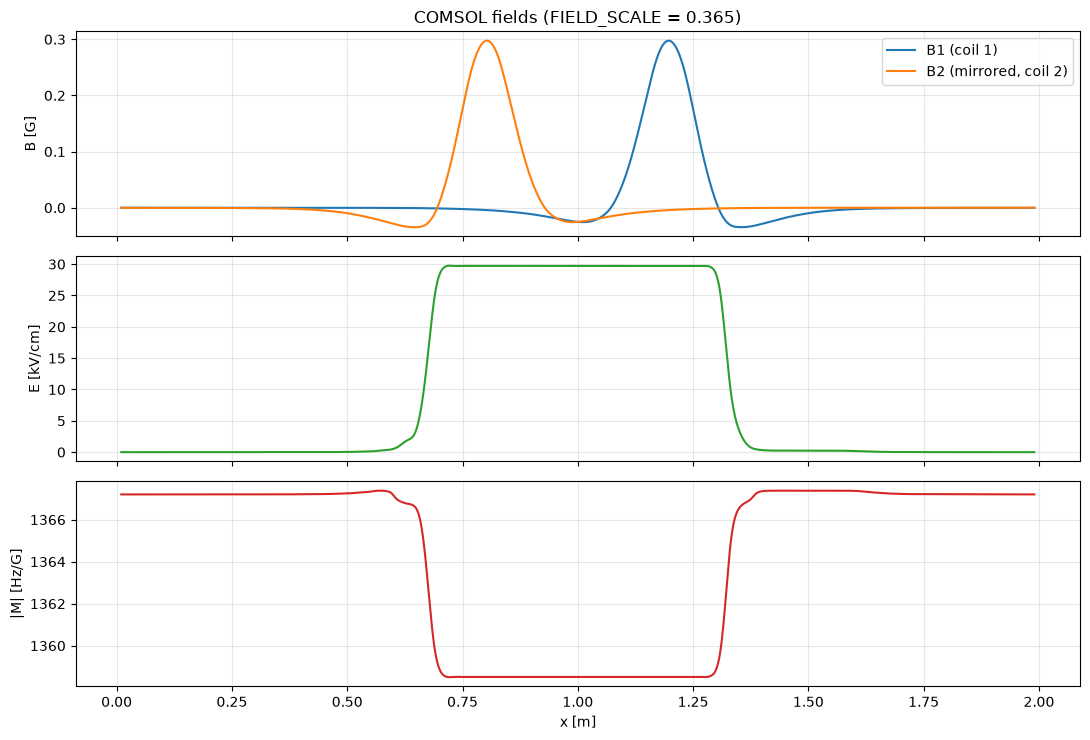

In [95]:
E_CONVERSION = 1e5      # V/m per kV/cm

def load_interp(path, header=None, kind="cubic"):
    """Cubic interpolation with extrapolation, matching Emma's load_interp."""
    df = pd.read_csv(path, header=header)
    x = df.iloc[:,0].values.astype(float)
    y = df.iloc[:,1].values.astype(float)
    return x, interp1d(x, y, kind=kind, fill_value="extrapolate")


class FieldModel:
    """Assembles Emma's CSVs into fields along z, sampled on a uniform time grid.

    Attributes: x, t, dt, T_total, B1, B2 [G, scaled], E_kVcm, M [Hz/G],
                nu_je [Hz], nu_rf [Hz].
    """

    def __init__(self, cfg, n_steps=None):
        self.cfg = cfg
        n_steps = n_steps or cfg.N_STEPS

        pos_B1, f_B1 = load_interp(cfg.path(cfg.B1_FILE))
        pos_B2, f_B2 = load_interp(cfg.path(cfg.B2_FILE))
        e_file = cfg.E_FILE_REAL if cfg.USE_REAL_FIELDS else cfg.E_FILE_ZERO
        pos_E, f_E = load_interp(cfg.path(e_file))

        self.x_start = max(pos_B1.min(), pos_B2.min(), pos_E.min())
        self.x_end   = min(pos_B1.max(), pos_B2.max(), pos_E.max())
        self.T_total = (self.x_end - self.x_start)/cfg.v_z

        self.t = np.linspace(0.0, self.T_total, n_steps)
        self.dt = self.t[1] - self.t[0]
        self.x = self.x_start + (self.x_end - self.x_start)*(self.t/self.T_total)

        self.B1 = f_B1(self.x)*cfg.FIELD_SCALE      # FIELD_SCALE on B only, as Emma does
        self.B2 = f_B2(self.x)*cfg.FIELD_SCALE
        self.E_Vm = f_E(self.x)

        if cfg.USE_REAL_FIELDS:
            E_c, f_M = load_interp(cfg.path(cfg.COUPLING_FILE))
            E_s, f_nu = load_interp(cfg.path(cfg.SIBSPLIT_FILE), header=0)
            raw = self.E_Vm/E_CONVERSION
            self.E_kVcm = np.clip(raw, E_c.min(), E_c.max())
            self.M = f_M(self.E_kVcm)
            self.nu_je = np.abs(f_nu(np.clip(self.E_kVcm, E_s.min(), E_s.max())))*1e3
            self.clipped_lo = bool(np.any(raw < E_c.min()))
            self.clipped_hi = bool(np.any(raw > E_c.max()))
            # RF reference = transition frequency on the plateau + intended offset
            self.nu_rf = float(np.median(
                self.nu_je[self.E_kVcm > 0.9*self.E_kVcm.max()])) + cfg.nu_rf_offset_Hz
        else:
            # reproduce ramsey4matrix.py: constant coupling, zero detuning
            E_c, f_M = load_interp(cfg.path(cfg.COUPLING_FILE_CONST))
            self.E_kVcm = np.clip(self.E_Vm/E_CONVERSION, E_c.min(), E_c.max())
            self.M = f_M(self.E_kVcm)
            self.nu_je = np.zeros_like(self.x)
            self.nu_rf = 0.0
            self.clipped_lo = self.clipped_hi = False

        self.x_peak1 = self.x[np.argmax(np.abs(self.B1))]
        self.x_peak2 = self.x[np.argmax(np.abs(self.B2))]
        self.separation = abs(self.x_peak1 - self.x_peak2)

    def summary(self):
        c = self.cfg
        print(f"domain      x = {self.x_start:.3f} .. {self.x_end:.3f} m")
        print(f"flight time {self.T_total*1e3:.3f} ms  (v_z = {c.v_z} m/s), "
              f"{len(self.t)} steps, dt = {self.dt*1e6:.3f} us")
        print(f"B1 peak     {np.abs(self.B1).max():.4f} G @ x = {self.x_peak1:.3f} m")
        print(f"B2 peak     {np.abs(self.B2).max():.4f} G @ x = {self.x_peak2:.3f} m")
        print(f"separation  {self.separation:.3f} m -> nominal Ramsey time "
              f"{self.separation/c.v_z*1e3:.3f} ms")
        print(f"E           {self.E_kVcm.min():.4f} .. {self.E_kVcm.max():.4f} kV/cm")
        print(f"|M|         {self.M.min():.2f} .. {self.M.max():.2f} Hz/G")
        if c.USE_REAL_FIELDS:
            print(f"nu_je       {self.nu_je.min():.1f} .. {self.nu_je.max():.1f} Hz")
            print(f"nu_rf       {self.nu_rf:.4f} Hz "
                  f"(plateau + offset {c.nu_rf_offset_Hz:+.2f} Hz)")
        if self.clipped_lo: print("  WARNING: E below lookup range, clipped")
        if self.clipped_hi: print("  WARNING: E above lookup range, clipped")


FM = FieldModel(CONFIG)
FM.summary()

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
axes[0].plot(FM.x, FM.B1, label="B1 (coil 1)")
axes[0].plot(FM.x, FM.B2, label="B2 (mirrored, coil 2)")
axes[0].set_ylabel("B [G]"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title(f"COMSOL fields (FIELD_SCALE = {CONFIG.FIELD_SCALE})")
axes[1].plot(FM.x, FM.E_kVcm, color="C2"); axes[1].set_ylabel("E [kV/cm]")
axes[1].grid(alpha=.3)
axes[2].plot(FM.x, FM.M, color="C3"); axes[2].set_ylabel("|M| [Hz/G]")
axes[2].set_xlabel("x [m]"); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()


---
# §2 Propagators

## Convention (identical to Emma's `ramsey4matrix.py`)

$$H_{\rm rot}=\frac12\begin{pmatrix}-\delta & \Omega_c^{*}\\ \Omega_c & \delta\end{pmatrix},
\qquad \Omega_c(z)=2\pi M(E(z))\big[B_1(z)+B_2(z)e^{i\varphi_2}\big]$$

$$\delta(z)/2\pi=\nu_{\rm RF}-\Big[\nu_{je}(E(z))
+\tfrac{\partial\nu}{\partial B_z}B_\parallel
+\tfrac12\tfrac{\partial^2\nu}{\partial B_\perp^2}B_\perp^2
+s\,\nu_S\Big]$$

with $\delta=\omega_{\rm RF}-\omega_0$. With `USE_REAL_FIELDS = False` this reduces to
$\nu_{je}\equiv0$, $\nu_{\rm RF}=0$.

## 2×2 exponential in closed form

$H$ is traceless, so with $H=\mathbf h\cdot\boldsymbol\sigma$ and
$|\mathbf h|=\tfrac12\sqrt{\delta^2+|\Omega_c|^2}$,

$$U=\cos(|\mathbf h|dt)\,\mathbb 1-i\,\frac{\sin(|\mathbf h|dt)}{|\mathbf h|}H$$

**Exact**, not an approximation, and much faster than calling `expm` per step (§4.2 verifies;
§5 Monte Carlo needs the speed). Emma renormalizes each step; with a unitary propagator this
only cleans up rounding, so it is an option here rather than the default.

P_e at midpoint = 0.540044   (0.5 expected after an ideal pi/2)
P_e final       = 0.557850
norm            = 1.000000000000


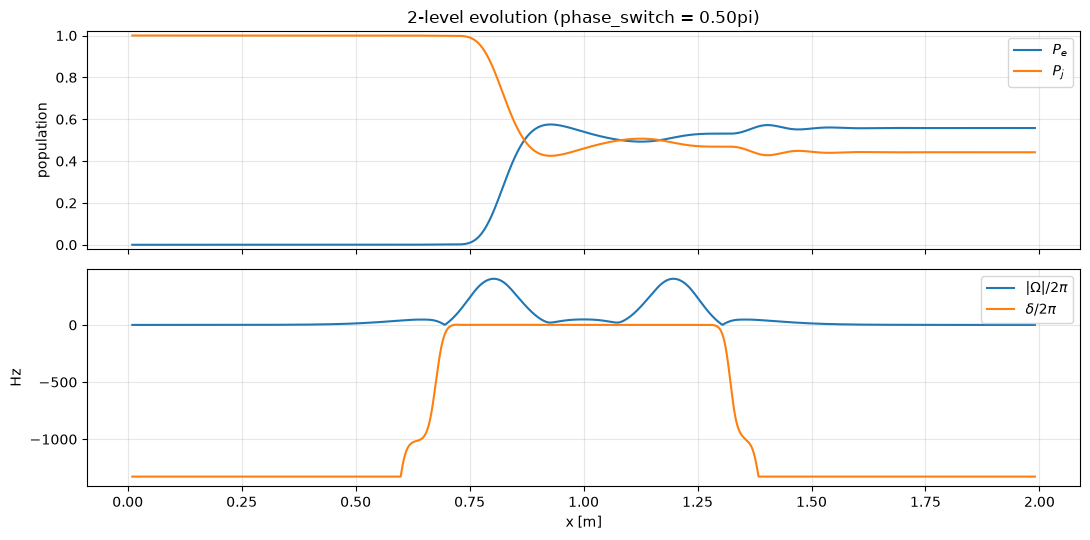

In [96]:
def su2_propagator(delta, Omega_c, dt):
    """U = exp(-i H dt) for H = 0.5*[[-delta, conj(Om)],[Om, delta]], closed form.
    delta, Omega_c in rad/s; dt in s."""
    h_x, h_y, h_z = Omega_c.real/2.0, Omega_c.imag/2.0, -delta/2.0
    hn = np.sqrt(h_x*h_x + h_y*h_y + h_z*h_z)
    if hn < 1e-30:
        return np.eye(2, dtype=complex)
    H = np.array([[h_z, h_x - 1j*h_y], [h_x + 1j*h_y, -h_z]], dtype=complex)
    return np.cos(hn*dt)*np.eye(2, dtype=complex) - 1j*(np.sin(hn*dt)/hn)*H


def rabi_and_detuning(cfg, coef, fm, phase_switch=0.0, B_par=None,
                      dnu_transverse=None, schiff_sign=0, extra_Hz=0.0):
    """Complex Rabi Omega_c(z) and detuning delta(z), both rad/s.

    B_par          : field along E in G; enters linearly via dnu/dB_z (exact).
    dnu_transverse : the transverse contribution as a frequency shift in Hz,
                     precomputed by direct diagonalization in §0. Defaults to the
                     measured value. Do NOT rebuild it from a second-derivative
                     coefficient -- those are ill conditioned at B_par = 0.
    """
    n = len(fm.x)
    def as_field(v, default):
        return np.broadcast_to(np.asarray(default if v is None else v, dtype=float), (n,))
    B_par = as_field(B_par, cfg.B_par_G)
    dnu_t = as_field(dnu_transverse, DNU_TRANSVERSE)

    phase_2 = cfg.phase_base + phase_switch
    Omega_c = 2*np.pi*fm.M*(fm.B1 + fm.B2*np.exp(1j*phase_2))

    nu0 = (fm.nu_je
           + coef['dnu_dB'][2]*B_par     # Zeeman, first order, B//E only (exact)
           + dnu_t                       # transverse, from direct diagonalization
           + schiff_sign*cfg.nu_schiff_Hz
           + extra_Hz)
    return Omega_c, 2*np.pi*(fm.nu_rf - nu0)


def propagate_2level(cfg, coef, fm, phase_switch=0.0, psi0=None,
                     renormalize=False, store=False, **kw):
    """Propagate the 2-level state along z. Returns (psi, history or None)."""
    Omega_c, delta = rabi_and_detuning(cfg, coef, fm, phase_switch=phase_switch, **kw)
    psi = np.array([1.0, 0.0], dtype=complex) if psi0 is None else psi0.astype(complex)
    hist = np.empty((len(fm.t), 2), dtype=complex) if store else None
    for k in range(len(fm.t)):
        psi = su2_propagator(delta[k], Omega_c[k], fm.dt) @ psi
        if renormalize:
            psi /= np.linalg.norm(psi)
        if store:
            hist[k] = psi
    return psi, hist


psi, hist = propagate_2level(CONFIG, COEF, FM,
                             phase_switch=CONFIG.phase_switch, store=True)
P_e = np.abs(hist[:,1])**2
print(f"P_e at midpoint = {P_e[len(P_e)//2]:.6f}   (0.5 expected after an ideal pi/2)")
print(f"P_e final       = {P_e[-1]:.6f}")
print(f"norm            = {(np.abs(hist[-1])**2).sum():.12f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
axes[0].plot(FM.x, P_e, label=r"$P_e$"); axes[0].plot(FM.x, 1-P_e, label=r"$P_j$")
axes[0].set_ylabel("population"); axes[0].set_ylim(-0.02, 1.02)
axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title(f"2-level evolution (phase_switch = {CONFIG.phase_switch/np.pi:.2f}pi)")
Om, dl = rabi_and_detuning(CONFIG, COEF, FM, phase_switch=CONFIG.phase_switch)
axes[1].plot(FM.x, np.abs(Om)/(2*np.pi), label=r"$|\Omega|/2\pi$")
axes[1].plot(FM.x, dl/(2*np.pi), label=r"$\delta/2\pi$")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("Hz")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 8-level propagator (|mJ|=1 subspace, lab frame)

For bounding the 2-level error (consequence d), not for Monte Carlo.

- **Only the 8 |mJ|=1 levels.** The mJ=0 levels are 21 GHz away; keeping them would force
  the time step to resolve 21 GHz.
- **Lab frame, no RWA.** The 8 levels have different frequencies, so no single rotating
  frame makes all drive terms static. Resolving the 119.5 kHz cosine over ~11 ms
  (≈1300 RF cycles) needs ~2e5 steps of an 8×8 exponential — **minutes per call.**

Subtracting the 2-level RWA result gives the pulse pull plus Bloch-Siegert terms.

In [97]:
def propagate_8level(cfg, coef, fm, cache, phase_switch=0.0, B_par=None,
                     schiff_sign=0, extra_Hz=0.0, n_steps=None, progress=True):
    """H(t) = H0(z) + B_total(z(t), t) * V_rf in the lab frame (real field, no RWA).

    Three things this has to get right to be comparable with the 2-level result:

    1. **nu_je must carry its z dependence.** The lookup table runs from 119521.6 Hz on
       the plateau to 120851.7 Hz in the fringes, and the 2-level propagator uses that
       z-dependent value. Holding the level energies fixed at their plateau values (an
       earlier version of this function did) is a ~1 kHz error in the fringe regions.
    2. **The same reference frequency as the 2-level path.** `cache['block_nu']` is from
       centrex_tlf and its j-e splitting differs from the lookup table's by ~1.3 Hz
       (the unresolved discrepancy in §0.5). Here the e level is pinned to the table so
       both paths share one reference; the other six levels keep their centrex_tlf
       offsets, whose own E dependence only enters through off-resonant second order.
    3. **Midpoint sampling of the oscillatory drive.** Left-endpoint sampling is only
       first order and biases the accumulated phase over ~1300 RF cycles.
    """
    n_steps = n_steps or cfg.N_STEPS_8LEVEL
    bj, be = int(cache['block_j']), int(cache['block_e'])
    B_par = cfg.B_par_G if B_par is None else B_par

    # Level offsets relative to j, from centrex_tlf, for every level except e.
    nu_off = (cache['block_nu'] - cache['block_nu'][bj]).copy()

    Vrf = 2*np.pi*(cache['block_HZ'][cfg.rf_axis] if cfg.rf_kind == "B"
                   else cache['block_HS'][cfg.rf_axis]).astype(complex)
    M_ref = abs(coef['me_B'][cfg.rf_axis] if cfg.rf_kind == "B"
                else coef['me_E'][cfg.rf_axis])

    omega_rf = 2*np.pi*fm.nu_rf
    phase_2 = cfg.phase_base + phase_switch

    t = np.linspace(0.0, fm.T_total, n_steps); dt = t[1]-t[0]
    tm = t + dt/2                                     # midpoint, see (3)
    x = fm.x_start + (fm.x_end-fm.x_start)*(t/fm.T_total)
    B1, B2 = np.interp(x, fm.x, fm.B1), np.interp(x, fm.x, fm.B2)
    scale = np.interp(x, fm.x, fm.M)/M_ref            # E dependence of the coupling
    # The j-e splitting at each z, exactly as the 2-level path builds it, see (1) and (2).
    nu_je_z = (np.interp(x, fm.x, fm.nu_je)
               + coef['dnu_dB'][2]*B_par + DNU_TRANSVERSE
               + schiff_sign*cfg.nu_schiff_Hz + extra_Hz)

    eye = np.eye(len(nu_off), dtype=complex)
    psi = np.zeros(len(nu_off), dtype=complex); psi[bj] = 1.0
    mark = max(1, n_steps//20)
    for k in range(n_steps):
        nu_b = nu_off.copy()
        nu_b[be] = nu_je_z[k]
        drive = B1[k]*np.cos(omega_rf*tm[k]) + B2[k]*np.cos(omega_rf*tm[k] + phase_2)
        H = 2*np.pi*np.diag(nu_b).astype(complex) + scale[k]*drive*Vrf
        psi = expm(-1j*H*dt) @ psi
        if progress and k % mark == 0:
            print(f"    {100*k//n_steps:3d}%", end="\r")
    if progress: print("    100%  ")
    return psi, bj, be


cache = dict(np.load(cache_path))
bj0 = int(cache['block_j'])
print(f"cache v{int(cache['cache_version'])}, {cache['block_nu'].size} levels")
print(f"subspace frequencies rel. j [kHz]: "
      f"{np.round((cache['block_nu']-cache['block_nu'][bj0])/1e3, 3)}")
print(f"\nReady. §4.3 calls this; {CONFIG.N_STEPS_8LEVEL} steps of 8x8 expm per call.")


cache v2, 8 levels
subspace frequencies rel. j [kHz]: [-26.022 -22.771   0.      0.002 108.925 108.926 119.52  119.527]

Ready. §4.3 calls this; 200000 steps of 8x8 expm per call.


---
# §3 Readout and statistical sensitivity

The experiment detects **both spin states**, so the per-shot observable is the channel
asymmetry

$$A=\frac{N_j-N_e}{N_j+N_e}=1-2P_e$$

and the RF phase is set so that $A=0$ at balance — the zero crossing, where the phase
slope is largest. That operating phase is solved for once below and then held **fixed**;
it must not be re-solved when fields or velocity change, or it would absorb the very
shifts being measured.

(This replaces an earlier placeholder here that formed $A$ from the difference between
±π/2 phase settings. The ±π/2 phase switch is a *calibration* reversal, not the thing that
forms the asymmetry — see §3.5.)

## Shot noise, including the photon budget

With $N$ molecules and perfect state readout, $\sigma_A=1/\sqrt N$. Real readout is
fluorescence with a small photon budget, which inflates this. Each molecule scatters
$n_e$ photons before being pumped out — a geometric variable truncated at
`cycles_per_window` — and each photon is detected with probability $\eta$. Writing $m_d$,
$\sigma_d^2$ for the mean and variance of the *detected* count per molecule, and forming
$A$ from detected photons, at balance

$$\sigma_A=\frac{1}{\sqrt N}\sqrt{1+\frac{\sigma_d^2}{m_d^2}}\;\equiv\;\frac{F}{\sqrt N}$$

With the `centrex_asymmetry` reference numbers (pump-out 0.4823, 50 cycles, $\eta=0.052$)
this gives $m_d\approx0.108$ detected photons per molecule and $F\approx3.2$ — so the
photon budget costs a factor ~3 in sensitivity, or ~10 in molecule number. Any sensitivity
quoted at $1/\sqrt N$ is optimistic by that factor.

$$\delta\nu=\frac{\sigma_A}{|\partial A/\partial\nu|},\qquad
|\partial A/\partial\nu|=2\pi C\,T_{\rm eff}$$

**$T_{\rm eff}$ is not an input.** The geometry comes from the data and the two coil fields
overlap, so the effective Ramsey time is emergent; it is recovered from the numerical slope
as $T_{\rm eff}=|\partial A/\partial\nu|/(2\pi C)$ and compared against
(coil separation)/$v_z$ as a check on the geometry.

operating phase (A=0) = +1.686818 rad = +0.536931 pi
  (Emma's B2_PHASE = pi/2 = +1.570796; difference +0.116022 rad)

A at operating point = -4.285e-14  (P_e = 0.500000)  -- should be ~0
contrast C  = 0.999674
dA/dnu      = +1.523662e-02 1/Hz

T_eff (from slope)    = 2.4258 ms
separation / v_z      = 2.1868 ms (0.394 m)
total flight time     = 11.0000 ms
  T_eff should sit between these two; otherwise the geometry is misunderstood.

Photon budget: 2.074 emitted, 0.1078 detected per molecule -> excess-noise factor F = 3.211
Sensitivity (N=7e+07/shot, 50.0 Hz, duty=1.0):
  sigma_A           3.8377e-04  (perfect readout would be 1.1952e-04)
  per shot          2.5187e-02 Hz
  per sqrt(Hz)      3.5621e-03 Hz/sqrt(Hz)
  one day           1.2118e-05 Hz  (3.02e+14 molecules)


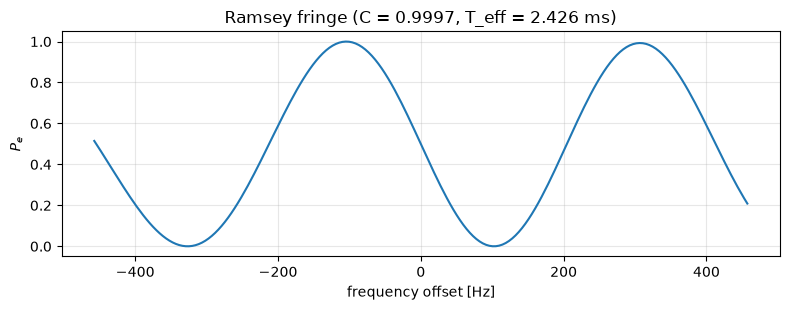

In [98]:
def P_excited(cfg, coef, fm, phase_switch=0.0, **kw):
    """Final e-state population. phase_switch is an EXTRA coil-2 phase on top of
    cfg.phase_base (used for the calibration reversal, not to form the asymmetry)."""
    return abs(propagate_2level(cfg, coef, fm, phase_switch=phase_switch, **kw)[0][1])**2


def channel_asymmetry(cfg, coef, fm, phase_switch=0.0, **kw):
    """A = (N_j - N_e)/(N_j + N_e) = 1 - 2*P_e. Both spin states are detected."""
    return 1.0 - 2.0*P_excited(cfg, coef, fm, phase_switch=phase_switch, **kw)


def find_operating_phase(cfg, coef, fm, bracket=(-np.pi, np.pi), n_scan=25):
    """Solve for the coil-2 phase giving A = 0 (the zero crossing, max phase slope).

    For the main configuration, solve ONCE and hold fixed -- re-solving as fields
    or velocity change would absorb the shifts being measured. §5 deliberately
    re-nulls per configuration, which is what the experiment does before a scan.

    n_scan only has to bracket the steepest crossing; brentq does the rest. 25 is
    enough for this near-sinusoidal A(phase) and keeps §5's repeated calls cheap.
    """
    grid = np.linspace(*bracket, n_scan)
    cfg0 = Config(**{**cfg.__dict__, "phase_base": 0.0})
    A = np.array([channel_asymmetry(cfg0, coef, fm, phase_switch=float(p)) for p in grid])
    sign_change = np.nonzero(np.diff(np.sign(A)))[0]
    if sign_change.size == 0:
        raise RuntimeError("no A=0 crossing found in the bracket")
    # Prefer the crossing with the steepest slope (the useful working point).
    best = sign_change[np.argmax(np.abs(np.diff(A)[sign_change]))]
    return brentq(lambda p: channel_asymmetry(cfg0, coef, fm, phase_switch=float(p)),
                  grid[best], grid[best+1], xtol=1e-12)


def readout_asymmetry(cfg, coef, fm, **kw):
    """Kept for the transfer-function checks in §5. Returns (A, P_e, 1-P_e)."""
    Pe = P_excited(cfg, coef, fm, **kw)
    return 1.0 - 2.0*Pe, Pe, 1.0 - Pe


def fringe_scan(cfg, coef, fm, nu_offsets, phase_switch=0.0):
    return np.array([P_excited(cfg, coef, fm, phase_switch=phase_switch,
                               extra_Hz=float(d)) for d in nu_offsets])


def measure_contrast(cfg, coef, fm, span_Hz=None, n=201):
    """C = (max-min)/(max+min) over roughly two fringe periods."""
    span = span_Hz if span_Hz else 2.0*cfg.v_z/max(fm.separation, 1e-3)
    nu = np.linspace(-span/2, span/2, n)
    P = fringe_scan(cfg, coef, fm, nu)
    return (P.max()-P.min())/(P.max()+P.min()), nu, P


def slope_dA_dnu(cfg, coef, fm, h_Hz=0.01):
    Ap, _, _ = readout_asymmetry(cfg, coef, fm, extra_Hz=+h_Hz)
    Am, _, _ = readout_asymmetry(cfg, coef, fm, extra_Hz=-h_Hz)
    return (Ap-Am)/(2*h_Hz)


def photon_noise_factor(cfg):
    """Excess-noise factor F = sqrt(1 + var_detected/mean_detected^2) per molecule.

    Photons per molecule are geometric in the per-attempt pump-out probability,
    truncated at cycles_per_window, then Bernoulli-thinned by the detection
    efficiency. Formulas match centrex_beam.photon_cycling.detected_photon_moments.
    F = 1 would be perfect single-molecule state readout.
    """
    b, r, eta = cfg.pumpout_probability, int(cfg.cycles_per_window), cfg.detection_efficiency
    k = np.arange(1, r+1, dtype=float)
    p = np.empty(r)
    if r > 1:
        p[:-1] = b*(1.0-b)**(k[:-1]-1.0)
    p[-1] = (1.0-b)**(r-1)                      # survives to the last attempt
    m_e = float(p @ k)
    v_e = float(p @ (k*k) - m_e**2)
    m_d = eta*m_e
    v_d = eta*(1-eta)*m_e + eta**2*v_e
    return dict(F=float(np.sqrt(1.0 + v_d/m_d**2)), mean_emitted=m_e,
                mean_detected=m_d, var_detected=v_d)


def sensitivity(cfg, contrast, slope, N=None, include_photon_noise=True):
    """Statistical sensitivity in Hz. T_eff is recovered from the slope, not assumed."""
    N = N or cfg.N_per_shot
    ph = photon_noise_factor(cfg)
    F = ph['F'] if include_photon_noise else 1.0
    T_eff = abs(slope)/(2*np.pi*contrast) if contrast > 0 else np.nan
    sigma_A = F/np.sqrt(N)
    dnu = sigma_A/abs(slope) if slope else np.nan
    sps = cfg.rep_rate_Hz*cfg.duty_cycle
    out = {k: v for k, v in ph.items() if k != 'F'}   # 'F' below may be overridden to 1
    return dict(T_eff=T_eff, F=F, sigma_A=sigma_A, per_shot=dnu,
                per_sqrt_Hz=dnu/np.sqrt(sps), per_day=dnu/np.sqrt(sps*86400),
                N_total_day=N*sps*86400, **out)


# Solve the operating phase ONCE, then freeze it into CONFIG.
OP_PHASE = find_operating_phase(CONFIG, COEF, FM)
CONFIG.phase_base = OP_PHASE
FM = FieldModel(CONFIG)          # rebuild so nothing stale is reused
print(f"operating phase (A=0) = {OP_PHASE:+.6f} rad = {OP_PHASE/np.pi:+.6f} pi")
print(f"  (Emma's B2_PHASE = pi/2 = {np.pi/2:+.6f}; "
      f"difference {OP_PHASE-np.pi/2:+.6f} rad)")

A0, Pe0, Pj0 = readout_asymmetry(CONFIG, COEF, FM)
C_num, nu_scan, P_scan = measure_contrast(CONFIG, COEF, FM)
slope = slope_dA_dnu(CONFIG, COEF, FM)
S = sensitivity(CONFIG, C_num, slope)

print(f"\nA at operating point = {A0:+.3e}  (P_e = {Pe0:.6f})  -- should be ~0")
print(f"contrast C  = {C_num:.6f}")
print(f"dA/dnu      = {slope:+.6e} 1/Hz")
print(f"\nT_eff (from slope)    = {S['T_eff']*1e3:.4f} ms")
print(f"separation / v_z      = {FM.separation/CONFIG.v_z*1e3:.4f} ms "
      f"({FM.separation:.3f} m)")
print(f"total flight time     = {FM.T_total*1e3:.4f} ms")
print("  T_eff should sit between these two; otherwise the geometry is misunderstood.")

print(f"\nPhoton budget: {S['mean_emitted']:.3f} emitted, {S['mean_detected']:.4f} "
      f"detected per molecule -> excess-noise factor F = {S['F']:.3f}")
print(f"Sensitivity (N={CONFIG.N_per_shot:.0e}/shot, {CONFIG.rep_rate_Hz} Hz, "
      f"duty={CONFIG.duty_cycle}):")
print(f"  sigma_A           {S['sigma_A']:.4e}  (perfect readout would be "
      f"{1/np.sqrt(CONFIG.N_per_shot):.4e})")
print(f"  per shot          {S['per_shot']:.4e} Hz")
print(f"  per sqrt(Hz)      {S['per_sqrt_Hz']:.4e} Hz/sqrt(Hz)")
print(f"  one day           {S['per_day']:.4e} Hz  ({S['N_total_day']:.2e} molecules)")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(nu_scan, P_scan); ax.set_xlabel("frequency offset [Hz]"); ax.set_ylabel(r"$P_e$")
ax.set_title(f"Ramsey fringe (C = {C_num:.4f}, T_eff = {S['T_eff']*1e3:.3f} ms)")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## §3b What if π/2 is applied instead of the solved operating phase?

The solved zero crossing is at 0.5316π, so setting the coil-to-coil phase to π/2 leaves a
constant phase error $\delta\varphi=\pi/2-0.5316\pi\approx-0.099$ rad. Worth knowing what
that costs, since π/2 is the natural thing to dial in when the optimum is unknown.

Three consequences, in increasing order of importance:

1. **Sensitivity**: the slope drops by $\cos\delta\varphi$ — here 0.5%. Negligible.
2. **$A_0\neq0$**: the readout sits off balance by $C\sin\delta\varphi\approx-0.099$.
   Useful as a diagnostic — $\delta\varphi$ can be read straight off $A_0$ and corrected,
   with no fringe scan needed.
3. **A multiplicative noise channel opens.** With $A_0\neq0$, any fractional drift in
   overall contrast or detection gain feeds straight through: $\delta A=A_0\,\delta C/C$.
   At the zero crossing $A_0=0$ and this vanishes. **This is the actual reason to work at
   the zero crossing**, and if the gain drift is reversal-correlated it is a systematic,
   not noise.

What it does *not* cost is $f_{\rm CP}$ itself — see §3.5c, which shows the parity
estimators are immune to a constant phase offset.

solved operating phase = +1.686818 rad = +0.536931 pi
applied phase          = +1.570796 rad = 0.500000 pi
phase error dphi       = -0.116022 rad = -0.036931 pi

                            A_0        P_e   contrast   dA/dnu [1/Hz]  per-shot dnu [Hz]
   operating (A=0)    -0.000000   0.500000   0.999674   +1.523662e-02         2.5187e-02
      applied pi/2    -0.115700   0.557850   0.999992   +1.513344e-02         2.5359e-02

slope ratio         = 0.993228   (cos(dphi) = 0.993277)
sensitivity penalty = +0.6818%
A_0 at pi/2         = -0.115700   (sin(dphi)*C = -0.115724)


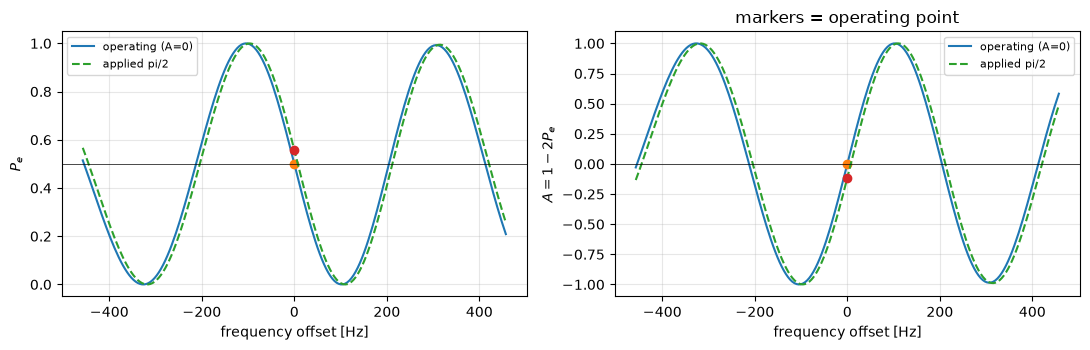

In [99]:
# §3b Applying pi/2 instead of the solved operating phase.
DPHI = np.pi/2 - OP_PHASE          # the phase error incurred
cfg_pi2 = Config(**{**CONFIG.__dict__, "phase_base": np.pi/2})

print(f"solved operating phase = {OP_PHASE:+.6f} rad = {OP_PHASE/np.pi:+.6f} pi")
print(f"applied phase          = {np.pi/2:+.6f} rad = 0.500000 pi")
print(f"phase error dphi       = {DPHI:+.6f} rad = {DPHI/np.pi:+.6f} pi\n")

PI2_ROWS = []
for nm, cfg_x in [("operating (A=0)", CONFIG), ("applied pi/2", cfg_pi2)]:
    fm_x = FieldModel(cfg_x)
    A_x, Pe_x, _ = readout_asymmetry(cfg_x, COEF, fm_x)
    C_x, nu_x, P_x = measure_contrast(cfg_x, COEF, fm_x)
    sl_x = slope_dA_dnu(cfg_x, COEF, fm_x)
    S_x = sensitivity(cfg_x, C_x, sl_x)
    PI2_ROWS.append(dict(name=nm, cfg=cfg_x, fm=fm_x, A0=A_x, Pe=Pe_x, C=C_x,
                         slope=sl_x, S=S_x, nu=nu_x, P=P_x))

print(f"{'':>18} {'A_0':>12} {'P_e':>10} {'contrast':>10} {'dA/dnu [1/Hz]':>15} "
      f"{'per-shot dnu [Hz]':>18}")
for r in PI2_ROWS:
    print(f"{r['name']:>18} {r['A0']:>+12.6f} {r['Pe']:>10.6f} {r['C']:>10.6f} "
          f"{r['slope']:>+15.6e} {r['S']['per_shot']:>18.4e}")

opt, pi2 = PI2_ROWS
print(f"\nslope ratio         = {pi2['slope']/opt['slope']:.6f}   "
      f"(cos(dphi) = {np.cos(DPHI):.6f})")
print(f"sensitivity penalty = {pi2['S']['per_shot']/opt['S']['per_shot'] - 1:+.4%}")
print(f"A_0 at pi/2         = {pi2['A0']:+.6f}   "
      f"(sin(dphi)*C = {np.sin(DPHI)*opt['C']:+.6f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for r, ls in zip(PI2_ROWS, ["-", "--"]):
    axes[0].plot(r['nu'], r['P'], ls, label=r['name'])
    axes[0].plot(0.0, r['Pe'], "o", ms=6)
    axes[1].plot(r['nu'], 1-2*r['P'], ls, label=r['name'])
    axes[1].plot(0.0, r['A0'], "o", ms=6)
axes[0].axhline(0.5, color="k", lw=0.5)
axes[0].set_xlabel("frequency offset [Hz]"); axes[0].set_ylabel(r"$P_e$")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].set_xlabel("frequency offset [Hz]"); axes[1].set_ylabel(r"$A = 1-2P_e$")
axes[1].set_title("markers = operating point"); axes[1].legend(fontsize=8)
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


In [100]:
# §3b continued: the cost that does NOT cancel -- gain/contrast drift via A_0.
#
#   dA = A_0 * (dC/C)   ->   equivalent frequency error dA / (dA/dnu)
#
# At the zero crossing A_0 = 0 and this channel is closed. Off it, the channel is open
# and is a SYSTEMATIC if the drift is reversal-correlated.
A0_pi2, slope_pi2 = pi2['A0'], pi2['slope']

print(f"At pi/2:  A_0 = {A0_pi2:+.6f},  dA/dnu = {slope_pi2:+.6e} 1/Hz\n")
print(f"{'contrast drift dC/C':>21} {'equiv. dnu [Hz]':>18}")
for rel in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"{rel:>21.1e} {abs(A0_pi2*rel/slope_pi2):>18.4e}")

print(f"\nCompare: per-shot statistical {S['per_shot']:.3e} Hz, "
      f"one day {S['per_day']:.3e} Hz")
for label, target in [("per-shot", S['per_shot']), ("one-day", S['per_day'])]:
    tol = abs(target*slope_pi2/A0_pi2)
    print(f"  to keep this below the {label} statistical limit: dC/C < {tol:.3e}")
print("\nThe one-day tolerance is the meaningful one, and it is tight -- which is the")
print("argument for measuring A_0 and correcting the phase rather than living with it.")

# --- A_0 as a phase diagnostic ---------------------------------------------
print(f"\n--- A_0 as a diagnostic: recover dphi from A_0 ---")
print(f"{'applied phase/pi':>17} {'A_0':>12} {'dphi inferred':>15} {'dphi true':>12} "
       f"{'error':>11}")
for frac in [0.48, 0.50, 0.5316, 0.55, 0.58]:
    cfg_s = Config(**{**CONFIG.__dict__, "phase_base": frac*np.pi})
    A_s, _, _ = readout_asymmetry(cfg_s, COEF, FieldModel(cfg_s))
    # A_0 = +sin(dphi)*C  ->  dphi = arcsin(A_0/C)   (sign checked against propagator)
    inferred = np.arcsin(np.clip(A_s/C_num, -1, 1))
    true = frac*np.pi - OP_PHASE
    print(f"{frac:>17.4f} {A_s:>+12.6f} {inferred:>+15.6f} {true:>+12.6f} "
          f"{inferred-true:>+11.3e}")
print("\nSo one whole-shot asymmetry measurement locates the zero crossing directly;")
print("no fringe scan is needed to set the phase.")


At pi/2:  A_0 = -0.115700,  dA/dnu = +1.513344e-02 1/Hz

  contrast drift dC/C    equiv. dnu [Hz]
              1.0e-04         7.6454e-04
              1.0e-03         7.6454e-03
              1.0e-02         7.6454e-02
              1.0e-01         7.6454e-01

Compare: per-shot statistical 2.519e-02 Hz, one day 1.212e-05 Hz
  to keep this below the per-shot statistical limit: dC/C < 3.294e-03
  to keep this below the one-day statistical limit: dC/C < 1.585e-06

The one-day tolerance is the meaningful one, and it is tight -- which is the
argument for measuring A_0 and correcting the phase rather than living with it.

--- A_0 as a diagnostic: recover dphi from A_0 ---
 applied phase/pi          A_0   dphi inferred    dphi true       error
           0.4800    -0.177886       -0.178897    -0.178854  -4.349e-05
           0.5000    -0.115700       -0.115998    -0.116022  +2.351e-05
           0.5316    -0.016726       -0.016732    -0.016747  +1.553e-05
           0.5500    +0.040977     

In [101]:
# Schiff response. The injected nu_S is a frequency shift, not the nuclear Schiff moment;
# converting requires a molecular structure factor, which is out of scope here.
Ap, _, _ = readout_asymmetry(CONFIG, COEF, FM, schiff_sign=+1)
Am, _, _ = readout_asymmetry(CONFIG, COEF, FM, schiff_sign=-1)
R = (Ap - Am)/(2*CONFIG.nu_schiff_Hz)

print(f"nu_S injected = {CONFIG.nu_schiff_Hz:.3e} Hz")
print(f"dA/dnu_S      = {R:+.6e} 1/Hz")
print(f"dA/dnu        = {slope:+.6e} 1/Hz   (background detuning)")
print(f"ratio         = {R/slope:+.6f}")
print("Ratio should be ~1: a Schiff shift is equivalent to any other frequency shift at")
print("readout. A significant departure means the two are injected inconsistently.")


nu_S injected = 1.000e-03 Hz
dA/dnu_S      = +1.523662e-02 1/Hz
dA/dnu        = +1.523662e-02 1/Hz   (background detuning)
ratio         = +1.000000
Ratio should be ~1: a Schiff shift is equivalent to any other frequency shift at
readout. A significant departure means the two are injected inconsistently.


---
# §3.5 Three-switch readout and CP extraction

Ported from `~/Documents/GitHub/centrex_asymmetry` (`centrex_beam/switching.py`), which
implements the reversal scheme the experiment actually uses. This supersedes reading the
CP frequency off a numerical slope: the scheme is **self-calibrating**, so it does not
need the contrast or $T_{\rm eff}$ as separate inputs.

Eight shot-level states $(d,p,c)\in\{-1,+1\}^3$:

| switch | realized as | role |
|---|---|---|
| $d$ | $\Delta f = d\,\Delta f_{\rm sw}$ | known detuning reversal → calibrates $T$ |
| $p$ | $\phi = p\,\phi_{\rm cal}$ | known phase reversal → calibrates the slope |
| $c$ | $\nu_S \to c\,\nu_S$ | the CP-odd reversal → carries the signal |

Near balance,

$$A_{dpc}\simeq A_0+G_A\big[p\,\phi_{\rm cal}+d\,2\pi\Delta f_{\rm sw}T+c\,\phi_{\rm CP}\big]$$

Define the equally weighted parities $A_q=\tfrac18\sum_{d,p,c}q\,A_{dpc}$ for
$q\in\{1,p,d,c\}$. Then

$$G_A=\frac{A_p}{\phi_{\rm cal}},\quad C=|G_A|,\quad
T=\frac{\phi_{\rm cal}}{2\pi\Delta f_{\rm sw}}\frac{A_d}{A_p},\quad
\phi_{\rm CP}=\phi_{\rm cal}\frac{A_c}{A_p},\quad
\boxed{f_{\rm CP}=\Delta f_{\rm sw}\frac{A_c}{A_d}}$$

The boxed ratio is the important one: **the phase calibration cancels**, so $f_{\rm CP}$
depends only on the known detuning reversal. Reference switch amplitudes from
`centrex_asymmetry`: $\Delta f_{\rm sw}=0.5$ Hz, $\phi_{\rm cal}=\pi/32$.

## Closure test

Inject a known $\nu_S$, run all eight states through the exact propagator, and check the
estimator returns it. This is a much stronger end-to-end test than any single-configuration
check, because it exercises the operating point, the sign conventions of all three
switches, and the propagator together.

Two caveats carried over from that repo's own notes:
- the estimators are ratios, so they are ill-conditioned unless $A_p$ and $A_d$ are
  significantly nonzero — keep the switch amplitudes large enough;
- the linearization assumes all three phases are small, so there is a second-order bias.

**Measured closure** (2026-09-22, this field configuration): $f_{\rm CP}$ is recovered to
$-2.0\times10^{-5}$ relative at $\Delta f_{\rm sw}=0.5$ Hz. The bias is **independent of
$\nu_S$** over four decades and scales as $\Delta f_{\rm sw}^2$
(−3×10⁻⁶ at 0.2 Hz, −2.0×10⁻⁵ at 0.5 Hz, −7.8×10⁻⁵ at 1.0 Hz), i.e. it comes from the
detuning-reversal linearization and not from the CP phase. So $\Delta f_{\rm sw}$ is the
knob that trades statistical conditioning against self-calibration bias.

In [102]:
# §3.5 Three-switch parity estimator
SWITCH_STATES = [(d, p, c) for d in (-1, 1) for p in (-1, 1) for c in (-1, 1)]


def run_three_switch(cfg, coef, fm, detuning_switch_Hz=None,
                     calibration_phase_rad=None, nu_cp_Hz=None):
    """Evaluate the channel asymmetry for all eight (d, p, c) states."""
    df = cfg.detuning_switch_Hz if detuning_switch_Hz is None else detuning_switch_Hz
    pc = cfg.calibration_phase_rad if calibration_phase_rad is None else calibration_phase_rad
    nu = cfg.nu_schiff_Hz if nu_cp_Hz is None else nu_cp_Hz
    if df == 0 or pc == 0:
        raise ValueError("detuning and calibration-phase amplitudes must be nonzero")

    cfg_cp = Config(**{**cfg.__dict__, "nu_schiff_Hz": nu})
    rows = []
    for d, p, c in SWITCH_STATES:
        A = channel_asymmetry(cfg_cp, coef, fm,
                              phase_switch=p*pc,        # calibration phase reversal
                              extra_Hz=d*df,            # detuning reversal
                              schiff_sign=c)            # CP reversal
        rows.append(dict(d=d, p=p, c=c, A=A))
    return pd.DataFrame(rows), df, pc, nu


def linear_switch_estimate(states, detuning_switch_Hz, calibration_phase_rad):
    """Parity estimators. Mirrors centrex_beam.switching._linear_parity_estimate."""
    A = states["A"].to_numpy(dtype=float)
    signs = dict(offset=np.ones(len(A)), phase=states["p"].to_numpy(float),
                 detuning=states["d"].to_numpy(float), cp=states["c"].to_numpy(float))
    par = {k: float(np.mean(s*A)) for k, s in signs.items()}
    if par["phase"] == 0 or par["detuning"] == 0:
        raise ValueError("phase and detuning parities must be nonzero")
    slope = par["phase"]/calibration_phase_rad
    return dict(
        A_offset=par["offset"], A_phase=par["phase"],
        A_detuning=par["detuning"], A_cp=par["cp"],
        phase_slope=slope, contrast=abs(slope),
        interaction_time_s=(calibration_phase_rad/(2*np.pi*detuning_switch_Hz)
                            * par["detuning"]/par["phase"]),
        cp_phase_rad=calibration_phase_rad*par["cp"]/par["phase"],
        cp_frequency_hz=detuning_switch_Hz*par["cp"]/par["detuning"],
    )


states, DF_SW, PHI_CAL, NU_CP = run_three_switch(CONFIG, COEF, FM)
est = linear_switch_estimate(states, DF_SW, PHI_CAL)

print(f"switch amplitudes: Delta_f_sw = {DF_SW} Hz, phi_cal = {PHI_CAL/np.pi:.5f} pi, "
      f"nu_CP injected = {NU_CP:.4e} Hz\n")
print(states.to_string(index=False,
                       formatters={"A": lambda v: f"{v:+.6e}"}))
print(f"\nparities:  A_0 = {est['A_offset']:+.4e}   A_p = {est['A_phase']:+.4e}")
print(f"           A_d = {est['A_detuning']:+.4e}   A_c = {est['A_cp']:+.4e}")
print(f"\nestimates:")
print(f"  contrast C          = {est['contrast']:.6f}   "
      f"(fringe-scan value {C_num:.6f})")
print(f"  interaction time T  = {est['interaction_time_s']*1e3:+.4f} ms   "
      f"(slope-derived {S['T_eff']*1e3:.4f} ms)")
print(f"  phi_CP              = {est['cp_phase_rad']:+.6e} rad")
print(f"  f_CP recovered      = {est['cp_frequency_hz']:+.6e} Hz")
print(f"  f_CP injected       = {NU_CP:+.6e} Hz")
print(f"  closure error       = {est['cp_frequency_hz']/NU_CP - 1:+.3e} (relative)")


switch amplitudes: Delta_f_sw = 0.5 Hz, phi_cal = 0.03125 pi, nu_CP injected = 1.0000e-03 Hz

 d  p  c             A
-1 -1 -1 -1.055460e-01
-1 -1  1 -1.055157e-01
-1  1 -1 +9.021113e-02
-1  1  1 +9.024148e-02
 1 -1 -1 -9.038351e-02
 1 -1  1 -9.035316e-02
 1  1 -1 +1.053745e-01
 1  1  1 +1.054048e-01

parities:  A_0 = -7.0813e-05   A_p = +9.7879e-02
           A_d = +7.5815e-03   A_c = +1.5163e-05

estimates:
  contrast C          = 0.996985   (fringe-scan value 0.999674)
  interaction time T  = +2.4206 ms   (slope-derived 2.4258 ms)
  phi_CP              = +1.520851e-05 rad
  f_CP recovered      = +9.999805e-04 Hz
  f_CP injected       = +1.000000e-03 Hz
  closure error       = -1.949e-05 (relative)


In [103]:
# §3.5b Linearity check: the closure error must vanish as nu_CP -> 0.
# A residual at large nu_CP is the expected second-order bias of the linearization,
# not a bug -- but it must scale away.
print(f"{'nu_CP [Hz]':>12} {'f_CP recovered [Hz]':>21} {'rel. error':>13}")
for nu in [1e-1, 1e-2, 1e-3, 1e-4]:
    st, df_, pc_, _ = run_three_switch(CONFIG, COEF, FM, nu_cp_Hz=nu)
    e = linear_switch_estimate(st, df_, pc_)
    print(f"{nu:>12.1e} {e['cp_frequency_hz']:>21.8e} "
          f"{e['cp_frequency_hz']/nu - 1:>+13.3e}")

print("\nAlso check the estimator is insensitive to the switch amplitudes themselves:")
print(f"{'Delta_f_sw [Hz]':>16} {'phi_cal/pi':>12} {'f_CP recovered [Hz]':>21} "
      f"{'T [ms]':>10}")
for df_sw in [0.2, 0.5, 1.0]:
    for phi in [np.pi/64, np.pi/32, np.pi/16]:
        st, d_, p_, n_ = run_three_switch(CONFIG, COEF, FM, detuning_switch_Hz=df_sw,
                                          calibration_phase_rad=phi, nu_cp_Hz=1e-3)
        e = linear_switch_estimate(st, d_, p_)
        print(f"{df_sw:>16.2f} {phi/np.pi:>12.5f} {e['cp_frequency_hz']:>21.8e} "
              f"{e['interaction_time_s']*1e3:>10.4f}")
print("\nSpread across these rows is the linearization error, which sets how large the")
print("switch amplitudes can be before the self-calibration starts to bias f_CP.")


  nu_CP [Hz]   f_CP recovered [Hz]    rel. error
     1.0e-01        9.99981281e-02    -1.872e-05
     1.0e-02        9.99980508e-03    -1.949e-05
     1.0e-03        9.99980505e-04    -1.949e-05
     1.0e-04        9.99980549e-05    -1.945e-05

Also check the estimator is insensitive to the switch amplitudes themselves:
 Delta_f_sw [Hz]   phi_cal/pi   f_CP recovered [Hz]     T [ms]
            0.20      0.01562        9.99996884e-04     2.4264
            0.20      0.03125        9.99996884e-04     2.4205
            0.20      0.06250        9.99996884e-04     2.3970
            0.50      0.01562        9.99980504e-04     2.4264
            0.50      0.03125        9.99980505e-04     2.4206
            0.50      0.06250        9.99980506e-04     2.3970
            1.00      0.01562        9.99922005e-04     2.4266
            1.00      0.03125        9.99922006e-04     2.4207
            1.00      0.06250        9.99922013e-04     2.3972

Spread across these rows is the linearization 

## §3.5c Immunity of the parity estimators to a constant phase offset

Follow-up to §3b. Write the readout as $A=C\sin\Phi$ with
$\Phi=\delta\varphi+p\,a+d\,b+c\,g$, where $a=\phi_{\rm cal}$,
$b=2\pi\Delta f_{\rm sw}T$, $g=\phi_{\rm CP}$, and $\delta\varphi$ is a constant operating
phase error. Expanding with $p,d,c=\pm1$ (so $\cos(pa)=\cos a$ and $\sin(pa)=p\sin a$) and
averaging:

$$A_0=C\sin\delta\varphi\,\cos a\cos b\cos g,\qquad
A_p=C\cos\delta\varphi\,\sin a\cos b\cos g$$
$$A_d=C\cos\delta\varphi\,\cos a\sin b\cos g,\qquad
A_c=C\cos\delta\varphi\,\cos a\cos b\sin g$$

The three signal parities share the factor $C\cos\delta\varphi$, so it **cancels in every
estimator**, each of which is a ratio:

$$f_{\rm CP}=\Delta f_{\rm sw}\frac{A_c}{A_d}=\Delta f_{\rm sw}\frac{\tan g}{\tan b},
\qquad T=\frac{\phi_{\rm cal}}{2\pi\Delta f_{\rm sw}}\frac{A_d}{A_p}
=\frac{\phi_{\rm cal}}{2\pi\Delta f_{\rm sw}}\frac{\tan b}{\tan a}$$

So $f_{\rm CP}$ and $T$ are immune to $\delta\varphi$ **to all orders**, and immune to the
contrast $C$ as well. Only the contrast estimate itself is affected, by the harmless factor
$\cos\delta\varphi$. Note also that $\tan g/\tan b$ is exact — the residual closure error
measured in §3.5 is entirely the $\tan b\neq b$ expansion, which is why it scaled as
$\Delta f_{\rm sw}^2$ and was independent of $\nu_S$.

$A_0$ is the one parity that does *not* carry $\cos\delta\varphi$; it carries
$\sin\delta\varphi$ instead, which is exactly why it works as the phase diagnostic in §3b.

**Measured** (scan below, $\delta\varphi$ from −0.41 to +0.37 rad): $f_{\rm CP}$ is flat to
$5\times10^{-8}$ relative — the cancellation is essentially exact. $T$ drifts by ~1% across
that range, which is *not* an estimator artifact: the derivation makes $T$ independent of
$\delta\varphi$ too, so the residual is physical. Because the two coil fields overlap, the
relative coil phase slightly moves where the effective precession interval starts and ends,
so the true $T_{\rm eff}$ does depend weakly on the operating phase.

The scan below checks all of this against the exact propagator over a wide range of
$\delta\varphi$, not just the 0.099 rad of the π/2 case.

In [104]:
# §3.5c Scan the operating phase error and check the estimators do not move.
print(f"nu_CP injected = {CONFIG.nu_schiff_Hz:.4e} Hz, "
      f"solved operating phase = {OP_PHASE/np.pi:.6f} pi\n")
print(f"{'phase/pi':>10} {'dphi [rad]':>11} {'A_0':>11} {'contrast':>10} "
      f"{'T [ms]':>10} {'f_CP [Hz]':>16} {'f_CP rel.err':>14}")
for frac in [0.40, 0.45, 0.50, OP_PHASE/np.pi, 0.55, 0.60, 0.65]:
    cfg_s = Config(**{**CONFIG.__dict__, "phase_base": frac*np.pi})
    fm_s = FieldModel(cfg_s)
    st, df_, pc_, nu_ = run_three_switch(cfg_s, COEF, fm_s)
    e = linear_switch_estimate(st, df_, pc_)
    A0_s, _, _ = readout_asymmetry(cfg_s, COEF, fm_s)
    tag_s = "  <== solved" if abs(frac - OP_PHASE/np.pi) < 1e-9 else ""
    print(f"{frac:>10.6f} {frac*np.pi-OP_PHASE:>+11.4f} {A0_s:>+11.6f} "
          f"{e['contrast']:>10.6f} {e['interaction_time_s']*1e3:>10.4f} "
          f"{e['cp_frequency_hz']:>16.8e} {e['cp_frequency_hz']/nu_-1:>+14.3e}{tag_s}")

print("\nf_CP and T columns should be flat; the contrast column should follow cos(dphi)")
print("and A_0 should follow -sin(dphi)*C. Departures at large |dphi| are where the")
print("linearization in phi_cal itself breaks down, not a failure of the cancellation.")


nu_CP injected = 1.0000e-03 Hz, solved operating phase = 0.536931 pi

  phase/pi  dphi [rad]         A_0   contrast     T [ms]        f_CP [Hz]   f_CP rel.err
  0.400000     -0.4302   -0.417634   0.910724     2.4054   9.99980806e-04     -1.919e-05
  0.450000     -0.2731   -0.269865   0.963544     2.4107   9.99980686e-04     -1.931e-05
  0.500000     -0.1160   -0.115700   0.991934     2.4163   9.99980579e-04     -1.942e-05
  0.536931     +0.0000   -0.000000   0.996985     2.4206   9.99980505e-04     -1.949e-05  <== solved
  0.550000     +0.0411   +0.040977   0.995541     2.4221   9.99980478e-04     -1.952e-05
  0.600000     +0.1981   +0.196284   0.974662     2.4279   9.99980379e-04     -1.962e-05
  0.650000     +0.3552   +0.346431   0.930194     2.4336   9.99980276e-04     -1.972e-05

f_CP and T columns should be flat; the contrast column should follow cos(dphi)
and A_0 should follow -sin(dphi)*C. Departures at large |dphi| are where the
linearization in phi_cal itself breaks down, not 

---
# §4 Validation

Run this before trusting §5.

- **4.1** reproduce Emma's `ramsey4matrix.py` — confirms the two codes agree
- **4.2** closed form vs `expm`, and step-count convergence
- **4.3** 2-level vs 8-level — quantifies consequence (d), the only effect here a 2-level
  model cannot see. Slow; run separately.
- **4.4** solve for the `FIELD_SCALE` that gives an exact π/2 first pulse

In [105]:
# 4.1 Reproduce ramsey4matrix.py: zero E, constant coupling 1370 Hz/G, zero detuning,
# FIELD_SCALE 0.365, B2_PHASE pi/2, 4000 steps, v = 180 m/s.
# (Using the correct B field filenames -- see the Configuration note.)
cfg_emma = Config(**{**CONFIG.__dict__, "USE_REAL_FIELDS": False, "v_z": 180.0,
                     "N_STEPS": 4000, "phase_base": 0.0, "phase_switch": np.pi/2})
FM_emma = FieldModel(cfg_emma)
FM_emma.summary()

_, hist_e = propagate_2level(cfg_emma, COEF, FM_emma,
                             phase_switch=cfg_emma.phase_switch,
                             renormalize=True, store=True)
for name, k in [("HALFWAY", len(hist_e)//2), ("FINAL", -1)]:
    cg, ce = hist_e[k]
    print(f"\n===== {name} =====")
    print(f"time                {FM_emma.t[k]:.6e} s")
    print(f"ground coefficient  {cg}")
    print(f"excited coefficient {ce}")
    print(f"ground population   {abs(cg)**2:.6f}")
    print(f"excited population  {abs(ce)**2:.6f}")
print("\nReference values from ramsey4matrix.py (after both fixes described in")
print("Configuration), which this cell should reproduce to ~1e-15:")
print("  T_TOTAL            0.011 s")
print("  halfway  Pg / Pe   0.566048 / 0.433952")
print("  final    Pg / Pe   0.544337 / 0.455663")
print("  final    cg        (0.6330995456929688-0.378843258898385j)")
print("  final    ce        (0.47731684991764656-0.4773168499176441j)")
print("\nVerified 2026-09-22: max |dpsi| = 3.7e-15 over 4000 steps, i.e. machine")
print("precision. Also checked separately that the closed-form SU(2) propagator and")
print("scipy.linalg.expm agree to 1.7e-16 on identical input (see also §4.2).")


domain      x = 0.010 .. 1.990 m
flight time 11.000 ms  (v_z = 180.0 m/s), 4000 steps, dt = 2.751 us
B1 peak     0.2976 G @ x = 1.197 m
B2 peak     0.2976 G @ x = 0.803 m
separation  0.394 m -> nominal Ramsey time 2.187 ms
E           0.0000 .. 0.0000 kV/cm
|M|         1370.00 .. 1370.00 Hz/G

===== HALFWAY =====
time                5.501375e-03 s
ground coefficient  (0.7509744894173308+0.04748641621283793j)
excited coefficient (0.6557503687193451+0.061431347405731695j)
ground population   0.566218
excited population  0.433782

===== FINAL =====
time                1.100000e-02 s
ground coefficient  (0.641791766745577-0.3555987783535553j)
excited coefficient (0.48044398059037535-0.48044398059037546j)
ground population   0.538347
excited population  0.461653

Reference values from ramsey4matrix.py (after both fixes described in
Configuration), which this cell should reproduce to ~1e-15:
  T_TOTAL            0.011 s
  halfway  Pg / Pe   0.566048 / 0.433952
  final    Pg / Pe   0.544337 /

In [106]:
# 4.2 Closed form vs expm, then step-count convergence.
Om, dl = rabi_and_detuning(CONFIG, COEF, FM, phase_switch=CONFIG.phase_switch)
psi_c = np.array([1.0, 0.0], dtype=complex)
psi_x = np.array([1.0, 0.0], dtype=complex)
for k in range(len(FM.t)):
    H = 0.5*np.array([[-dl[k], np.conj(Om[k])], [Om[k], dl[k]]], dtype=complex)
    psi_c = su2_propagator(dl[k], Om[k], FM.dt) @ psi_c
    psi_x = expm(-1j*H*FM.dt) @ psi_x
print(f"closed form: {psi_c}")
print(f"expm       : {psi_x}")
print(f"max diff   : {np.abs(psi_c-psi_x).max():.3e}  (machine precision expected)")

print(f"\n{'N_STEPS':>9} {'P_e final':>13} {'change':>14}")
prev = None
for n in [1000, 2000, 4000, 8000, 16000]:
    fm_n = FieldModel(Config(**{**CONFIG.__dict__, "N_STEPS": n}))
    pe = abs(propagate_2level(CONFIG, COEF, fm_n,
                              phase_switch=CONFIG.phase_switch)[0][1])**2
    print(f"{n:>9} {pe:>13.9f} {'' if prev is None else f'{pe-prev:+.3e}':>14}")
    prev = pe
print("Emma uses 4000. Increase if the 4000 -> 8000 change exceeds the precision needed.")


closed form: [0.33588 +0.941859j 0.009196+0.001371j]
expm       : [0.33588 +0.941859j 0.009196+0.001371j]
max diff   : 9.821e-16  (machine precision expected)

  N_STEPS     P_e final         change
     1000   0.000086291               
     2000   0.000086395     +1.036e-07
     4000   0.000086443     +4.856e-08
     8000   0.000086460     +1.730e-08
    16000   0.000086469     +8.947e-09
Emma uses 4000. Increase if the 4000 -> 8000 change exceeds the precision needed.


In [118]:
# 4.3 2-level vs 8-level: the non-perturbative pulse pull.
#
# BOTH sides must report the SAME observable: the channel asymmetry A = 1 - 2*P_e at
# phase_switch = 0, i.e. at the operating point.
#
# An earlier version of this cell compared the 2-level channel asymmetry against an
# 8-level (P(+pi/2) - P(-pi/2))/(sum) ratio left over from the old readout model. Those
# are different quantities -- the ratio is ~-1 in BOTH models -- so the O(1) "difference"
# it reported, equivalent to -65...-109 Hz, was entirely that mismatch and not physics.
#
# Reference from a 2-level cross-check run through this same lab-frame integrator
# (converged: 200k and 600k steps agree to 7e-6 in P_e): at the operating point the
# no-RWA minus RWA difference is -7.6e-4 in P_e, about +0.10 Hz equivalent. That is the
# pure Bloch-Siegert part. The 8-level run adds the multilevel contribution on top, and
# the §0 Floquet estimate for that is +0.2 Hz. So expect a few tenths of a Hz in total.
SCALES = [0.25, 0.365, 0.50]
N8 = 400_000          # 60k is NOT converged -- it biases the accumulated phase

rows = []
for fs in SCALES:
    cfg_s = Config(**{**CONFIG.__dict__, "FIELD_SCALE": fs})
    fm_s = FieldModel(cfg_s)
    P2 = P_excited(cfg_s, COEF, fm_s, phase_switch=0.0)
    sl = slope_dA_dnu(cfg_s, COEF, fm_s)

    print(f"FIELD_SCALE {fs}: 8-level at the operating point")
    psi, bj, be = propagate_8level(cfg_s, COEF, fm_s, cache,
                                   phase_switch=0.0, n_steps=N8)
    P8 = abs(psi[be])**2
    dA = (1.0 - 2.0*P8) - (1.0 - 2.0*P2)          # = -2*(P8 - P2)
    leak = 1.0 - abs(psi[bj])**2 - P8
    rows.append((fs, np.abs(fm_s.B1).max(), P2, P8, dA,
                 dA/sl if sl else np.nan, leak))

print(f"\n{'SCALE':>7} {'B peak[G]':>10} {'P_e(2-lvl)':>13} {'P_e(8-lvl)':>13} "
      f"{'dA':>11} {'equiv dnu[Hz]':>14} {'leakage':>10}")
for r in rows:
    print(f"{r[0]:>7.3f} {r[1]:>10.4f} {r[2]:>13.8f} {r[3]:>13.8f} "
          f"{r[4]:>+11.2e} {r[5]:>+14.4f} {r[6]:>10.2e}")

print("\nHow to read it:")
print("  'equiv dnu' is the pulse pull: Bloch-Siegert plus the multilevel contribution.")
print("  A few tenths of a Hz is the expected scale. Tens of Hz would mean something is")
print("  wrong with the setup, not a discovery -- check the observable definitions first.")
print("  Roughly CONSTANT across the scan -> a calibratable offset.")
print("  Scaling as B^2 -> the pulse-only Delta that Hyper-Ramsey targets.")
print("  'leakage' is population outside j/e, which directly reduces contrast.")
# --- what the pull actually constrains: RF amplitude stability ---------------
# The pull goes as B^2, so a fractional amplitude change dB/B shifts it by
# 2 * pull * (dB/B). As a COMMON offset across all eight switch states it cancels in
# the parity estimators (see §3.5c), so what matters is amplitude reproducibility
# ACROSS REVERSALS.
b_arr = np.array([r[1] for r in rows])
pull_arr = np.array([r[5] for r in rows])
print(f"\n--- B^2 scaling ---")
print(f"{'B peak[G]':>10} {'pull[Hz]':>10} {'pull/B^2 [Hz/G^2]':>19}")
for b, pl in zip(b_arr, pull_arr):
    print(f"{b:>10.4f} {pl:>10.4f} {pl/b**2:>19.3f}")

i_op = int(np.argmin(np.abs(b_arr - np.abs(FM.B1).max())))
pull_op = pull_arr[i_op]
print(f"\nAt the operating amplitude ({b_arr[i_op]:.4f} G): pull = {pull_op:+.4f} Hz")
print(f"  d(pull)/d(dB/B) = 2 * pull = {2*pull_op:+.4f} Hz per unit fractional change")
print(f"\nRF amplitude reproducibility required ACROSS REVERSALS:")
for nm, S_t in [("per shot", S['per_shot']), ("per day", S['per_day'])]:
    print(f"  to stay under the {nm} statistical limit ({S_t:.3e} Hz): "
          f"dB/B < {S_t/abs(2*pull_op):.3e}")
print(f"\nAlso: §5.2c recommends trimming the amplitude by +3.5% to null the velocity")
print(f"channel. That changes B^2 by +7.2%, moving the pull by "
      f"{0.072*pull_op:+.4f} Hz --")
print("common-mode, so harmless to f_CP, but it does move the fringe centre.")

print("\nTODO convergence: rerun with N8 = 400_000 and confirm the equiv dnu column")
print("moves by much less than the effect itself.")


FIELD_SCALE 0.25: 8-level at the operating point
    100%  
FIELD_SCALE 0.365: 8-level at the operating point
    100%  
FIELD_SCALE 0.5: 8-level at the operating point
    100%  

  SCALE  B peak[G]    P_e(2-lvl)    P_e(8-lvl)          dA  equiv dnu[Hz]    leakage
  0.250     0.2038    0.36955110    0.36915960   +7.83e-04        +0.0682   4.42e-09
  0.365     0.2976    0.50000000    0.49876144   +2.48e-03        +0.1626   1.52e-08
  0.500     0.4077    0.39086665    0.38857335   +4.59e-03        +0.3965   3.64e-08

How to read it:
  'equiv dnu' is the pulse pull: Bloch-Siegert plus the multilevel contribution.
  A few tenths of a Hz is the expected scale. Tens of Hz would mean something is
  wrong with the setup, not a discovery -- check the observable definitions first.
  Roughly CONSTANT across the scan -> a calibratable offset.
  Scaling as B^2 -> the pulse-only Delta that Hyper-Ramsey targets.
  'leakage' is population outside j/e, which directly reduces contrast.

--- B^2 scaling

In [108]:
# 4.4 Solve for the FIELD_SCALE giving an exact pi/2 pulse.
#
# Criterion: coil 1 ALONE should take P_e from 0 to 0.5. Switching coil 2 off makes
# this independent of the relative coil phase, which a midpoint-of-the-trajectory
# criterion is not: with phase_base now carrying the operating phase, a midpoint
# criterion measures the combined two-coil rotation and gives a different answer.
def P_e_coil1_only(field_scale):
    cfg_s = Config(**{**CONFIG.__dict__, "FIELD_SCALE": float(field_scale)})
    fm_s = FieldModel(cfg_s)
    fm_s.B2 = np.zeros_like(fm_s.B2)          # coil 1 alone -> phase irrelevant
    return P_excited(cfg_s, COEF, fm_s, phase_switch=0.0)

print(f"coil peaks x = {FM.x_peak1:.3f}, {FM.x_peak2:.3f} m\n")
print(f"{'FIELD_SCALE':>12} {'P_e (coil 1 alone)':>20}")
for fs in [0.15, 0.25, 0.365, 0.50, 0.70]:
    print(f"{fs:>12.3f} {P_e_coil1_only(fs):>20.6f}")

FS_PI2 = None
# Bracket below the first P_e = 1 turning point: P_e is not monotonic in amplitude
# (it passes through 1 and comes back down), so a wide bracket has two roots and
# can leave both endpoints on the same side.
try:
    FS_PI2 = brentq(lambda s: P_e_coil1_only(s)-0.5, 0.05, 0.60, xtol=1e-6)
    area_now = 2*np.arcsin(np.sqrt(P_e_coil1_only(CONFIG.FIELD_SCALE)))
    print(f"\nexact pi/2 at FIELD_SCALE = {FS_PI2:.5f} "
          f"({(FS_PI2-CONFIG.FIELD_SCALE)/CONFIG.FIELD_SCALE*100:+.2f}% vs "
          f"the {CONFIG.FIELD_SCALE} in use)")
    print(f"pulse area at {CONFIG.FIELD_SCALE} = {area_now/np.pi:.4f} pi "
          f"({area_now/(np.pi/2)-1:+.2%} vs pi/2)")
except ValueError as exc:
    print(f"\nno pi/2 root in [0.05, 0.60]: {exc}")

print("\nThis is the phase-independent pulse-area diagnostic. An earlier version of")
print("this cell used a trajectory-midpoint criterion, which the frozen operating")
print("phase polluted; the values it reported (0.399, 0.319) were both artifacts.")
print(f"On this diagnostic the {CONFIG.FIELD_SCALE} in use is a good pi/2 setting.")


coil peaks x = 1.197, 0.803 m

 FIELD_SCALE   P_e (coil 1 alone)
       0.150             0.095148
       0.250             0.249075
       0.365             0.477221
       0.500             0.747013
       0.700             0.985361

exact pi/2 at FIELD_SCALE = 0.37592 (+2.99% vs the 0.365 in use)
pulse area at 0.365 = 0.4855 pi (-2.90% vs pi/2)

This is the phase-independent pulse-area diagnostic. An earlier version of
this cell used a trajectory-midpoint criterion, which the frozen operating
phase polluted; the values it reported (0.399, 0.319) were both artifacts.
On this diagnostic the 0.365 in use is a good pi/2 setting.


## §4.5 External validation of the sensitivity formula

`centrex_asymmetry` has a fully calibrated main-IR production run to compare against
(its README, "Full 16-block projection and fluorescence run", 2026-09-17):

- 16 balanced blocks, 128 shots × 70M molecules = **8.96×10⁹** histories
- fluorescence readout with the photon budget used in §3
- injected $f_{\rm CP}=0$, recovered $(-1.872\pm4.841_{\rm block\,SEM})\times10^{-4}$ Hz
- **combined conditional uncertainty 4.0596×10⁻⁴ Hz**, against their own independent
  manuscript readout-noise prediction of 4.0747×10⁻⁴ Hz (0.37% apart)

That is an independently computed number for a geometry we can reproduce, so it tests the
whole §3 chain at once: the photon excess-noise factor $F$, the slope $2\pi C T$, and the
$1/\sqrt N$ scaling. Their geometry is the main IR, $T=2.5\,{\rm m}/184\,{\rm m/s}$.

In [109]:
# §4.5 Reproduce centrex_asymmetry's calibrated main-IR sensitivity.
N_BENCH = 128*70e6
T_BENCH = 2.5/184.0
SIGMA_REPORTED = 4.0596e-4      # Hz, their combined conditional uncertainty
F_BENCH = photon_noise_factor(CONFIG)['F']

print(f"N_total          = {N_BENCH:.4e} molecules (128 shots x 70M)")
print(f"T = 2.5/184      = {T_BENCH*1e3:.4f} ms")
print(f"photon factor F  = {F_BENCH:.4f}\n")
print(f"{'contrast':>10} {'predicted sigma(f_CP) [Hz]':>28} {'vs reported':>14}")
for C_b in (1.00, 0.97, 0.95):
    pred = F_BENCH/np.sqrt(N_BENCH)/(2*np.pi*C_b*T_BENCH)
    print(f"{C_b:>10.2f} {pred:>28.5e} {pred/SIGMA_REPORTED-1:>+14.2%}")
print(f"\nreported: {SIGMA_REPORTED:.5e} Hz")
print("\nAgreement is ~2% at unit contrast, which validates the sensitivity chain")
print("(F, the 2*pi*C*T slope, and 1/sqrt(N)) against an independent calculation.")
print("Their actual contrast is slightly below 1 because of the 16 m/s velocity")
print("spread, which would close the gap further; we do not model that spread here.")

# Same formula applied to this small-IR configuration, at equal molecule count.
pred_small = S['F']/np.sqrt(N_BENCH)/abs(slope)
print(f"\n--- same molecule count, this small-IR configuration ---")
print(f"T_eff            = {S['T_eff']*1e3:.4f} ms  (vs {T_BENCH*1e3:.4f} ms main IR)")
print(f"sigma(f_CP)      = {pred_small:.5e} Hz")
print(f"ratio to main IR = {pred_small/SIGMA_REPORTED:.3f}   "
      f"(T ratio predicts {T_BENCH/S['T_eff']:.3f})")
print("\nSo at equal molecule count the small IR is worse by roughly the ratio of")
print("interaction times, as expected -- the cost of the shorter region, nothing else.")


N_total          = 8.9600e+09 molecules (128 shots x 70M)
T = 2.5/184      = 13.5870 ms
photon factor F  = 3.2109

  contrast   predicted sigma(f_CP) [Hz]    vs reported
      1.00                  3.97344e-04         -2.12%
      0.97                  4.09633e-04         +0.90%
      0.95                  4.18257e-04         +3.03%

reported: 4.05960e-04 Hz

Agreement is ~2% at unit contrast, which validates the sensitivity chain
(F, the 2*pi*C*T slope, and 1/sqrt(N)) against an independent calculation.
Their actual contrast is slightly below 1 because of the 16 m/s velocity
spread, which would close the gap further; we do not model that spread here.

--- same molecule count, this small-IR configuration ---
T_eff            = 2.4258 ms  (vs 13.5870 ms main IR)
sigma(f_CP)      = 2.22628e-03 Hz
ratio to main IR = 5.484   (T ratio predicts 5.601)

So at equal molecule count the small IR is worse by roughly the ratio of
interaction times, as expected -- the cost of the shorter region, no

---
# §5 Noise channels

Three channels that must be kept separate — the same field fluctuation has wildly different
consequences depending on which one it falls into:

| channel | definition | consequence |
|---|---|---|
| **DC offset** | constant in time and across reversals | no false EDM by itself, but it creates Δν_bg, which amplifies v_z drift |
| **random jitter** | shot-to-shot, uncorrelated with reversals | statistical noise, averages down as 1/√N |
| **reversal-correlated** | synchronous with E reversal (or another reversal) | **systematic error, does not average down** |

So what is needed is not "1 mG" but how that 1 mG divides between these three.

Transfer functions:

$$\delta\nu=\frac{\partial\nu}{\partial B_z}\delta B_\parallel=-2.4865\ {\rm Hz/mG}
\times\delta B_\parallel[{\rm mG}],
\qquad\qquad \delta\nu=\Delta\nu_{\rm bg}\times\frac{\delta v}{v}$$

Δν_bg is itself set mostly by the DC magnetic field (or by the unexplained 8.87 Hz). That is
the multiplicative coupling: neither source does much alone.

## The measured residual field

Uniform-field measurement at the mid position (z = 44–88 cm), 18 h record. **The plot's Bx
is the component parallel to E**, so in the Hamiltonian frame:

| plot component | value | Hamiltonian axis | contribution to $\nu_{je}$ |
|---|---|---|---|
| **Bx (∥ E)** | **+0.45 mG** | z | **−1.119 Hz** — first order |
| By | −0.80 mG | transverse | together with Bz: |
| Bz | −7.40 mG | transverse | **+0.0115 Hz** — second order |

**The dominant residual component is in the harmless direction.** 7.44 mG of transverse
field contributes ~1% of what 0.45 mG of parallel field does. Consequence (a) is confirmed
with measured numbers, and the shielding requirement is much less demanding than "1 mG"
suggested — but it is a requirement on one *component*, which the measurement must resolve.

So the measured background detuning is
$$\Delta\nu_{\rm bg}\approx-1.108\ {\rm Hz}$$

Two caveats on how that number is used:

- It is a **DC** offset, so by itself it is not a false EDM; the operating phase solve in §3
  absorbs it (the fringe is nulled). What it does is set the amplifier for the velocity
  channel below.
- That amplification only survives if the fringe is nulled by adjusting the **phase**. If
  instead the RF *frequency* is tuned onto resonance, $\Delta\nu_{\rm bg}\to0$ and the
  velocity channel closes. **Which one the experiment does is a real question** — it
  changes the velocity-drift sensitivity by orders of magnitude. The code as written
  corresponds to phase nulling, the pessimistic case.
- Drift over 18 h: B_par spans ~0.44–0.50 mG, so ~0.05 mG → 0.12 Hz on an hours
  timescale. Bz drifts 0.3 mG but, being transverse and quadratic, contributes ~1 mHz.

## Velocity drift numbers

From the `centrex_asymmetry` beam model, which separates the two velocity scales — and the
separation maps exactly onto the channel table above:

| quantity | value | channel |
|---|---|---|
| shot **mean** velocity scatter | $\bar v_j\sim\mathcal N(184,4^2)$ m/s | **shot-to-shot**, so δv/v = **2.2%** per shot |
| spread **within** one shot | $v_{ij}\sim\mathcal N(\bar v_j,16^2)$ m/s | averages down within a shot |
| source time spread | $\mathcal N(0,(1\,{\rm ms})^2)$ | sets arrival-time spread, not phase directly |

The 1D centre-molecule model here sees only the shot-mean scale, which is the one that
matters: **2.2% per shot**.

**The naive estimate $\Delta\nu_{\rm bg}\times\delta v/v$ = 1.108 × 0.022 ≈ 0.024 Hz turns
out to be ~10× too small.** The measured response at the amplitude in use is **+0.241 Hz
per shot**, and §5.2b shows it is dominated by the *pulse-area* channel rather than the
precession-time channel. §5.2c then finds that the response has a zero crossing in RF
amplitude which coincides with the exact π/2 pulse area — so the channel is suppressible,
and the residual at 0.365 is just the 2.9% area error.

Note the response is nearly linear in $\varepsilon$, so a zero-mean random velocity scatter
averages down as $1/\sqrt{N_{\rm shots}}$ — it is **noise, not a systematic**. Only a
reversal-correlated velocity change would be a systematic.

Note that repo's own caution: arrival time does not uniquely determine velocity once source
times have a spread, so time-of-flight binning only partially resolves velocity. Its
workflow bins arrivals at 10 µs and **matches identical absolute bins across all eight
switch states** before forming parities — worth adopting if the velocity distribution is
ever put back in, since velocity correlates with arrival time.

In [110]:
# 5.1 Magnetic channel, with the MEASURED residual field
dnu_dBpar = COEF['dnu_dB'][2]
print(f"dnu/dB_par = {dnu_dBpar:.1f} Hz/G = {dnu_dBpar*1e-3:.4f} Hz/mG\n")

print("--- measured residual field, split by component ---")
print(f"  B_par  = {CONFIG.B_par_G*1e3:+.2f} mG  ->  "
      f"{dnu_dBpar*CONFIG.B_par_G:+.4f} Hz   <== the background detuning")
print(f"  B_perp = {B_PERP_MAG*1e3:.2f} mG  ->  {DNU_TRANSVERSE:+.4e} Hz "
      f"({abs(DNU_TRANSVERSE/(dnu_dBpar*CONFIG.B_par_G)):.1%} of the parallel term)")
print(f"  total background detuning Delta_nu_bg = "
      f"{dnu_dBpar*CONFIG.B_par_G + DNU_TRANSVERSE:+.4f} Hz")

print(f"\n--- linearity of the parallel channel ---")
print(f"{'B_par[mG]':>11} {'A':>13} {'equiv dnu[Hz]':>15} {'linear[Hz]':>13}")
for B in np.array([0.0, 0.1, 0.45, 1.0, 2.0])*1e-3:
    Ab, _, _ = readout_asymmetry(CONFIG, COEF, FM, B_par=B)
    print(f"{B*1e3:>11.2f} {Ab:>+13.6f} {(Ab-A0)/slope:>+15.5f} "
          f"{dnu_dBpar*(B-CONFIG.B_par_G):>+13.5f}")
print("  (equiv dnu is relative to the measured operating field, which is where A=0)")

print(f"\n--- drift over the 18 h record ---")
print(f"  B_par drift  {CONFIG.B_par_drift_G*1e3:.2f} mG  ->  "
      f"{abs(dnu_dBpar*CONFIG.B_par_drift_G):.4f} Hz")
dnu_t_drift = nu_je_at_field(
    Hfunc, Vt, IDX_J, IDX_E,
    [CONFIG.B_t1_G, CONFIG.B_t2_G - CONFIG.B_perp_drift_G, CONFIG.B_par_G]) - nu_par
print(f"  B_perp drift {CONFIG.B_perp_drift_G*1e3:.2f} mG  ->  "
      f"{abs(dnu_t_drift - DNU_TRANSVERSE):.4e} Hz")
print("  The transverse drift matters even less than the transverse field itself,")
print("  because the response is quadratic and the drift is a small fractional change.")

c_light = 299792458.0
B_mot_G = CONFIG.v_z*(CONFIG.E_plateau*1e3*100)/c_light**2*1e4
dnu_mot = nu_je_at_field(Hfunc, Vt, IDX_J, IDX_E,
                         [CONFIG.B_t1_G, CONFIG.B_t2_G + B_mot_G,
                          CONFIG.B_par_G]) - nu_full
print(f"\nMotional field v x E / c^2 = {B_mot_G*1e3:.4f} mG, perpendicular to E")
print(f"  -> adds {dnu_mot:+.3e} Hz on top of the measured field. "
      f"Negligible (consequence b).")


dnu/dB_par = -2486.4 Hz/G = -2.4864 Hz/mG

--- measured residual field, split by component ---
  B_par  = +0.45 mG  ->  -1.1189 Hz   <== the background detuning
  B_perp = 7.44 mG  ->  +1.1496e-02 Hz (1.0% of the parallel term)
  total background detuning Delta_nu_bg = -1.1074 Hz

--- linearity of the parallel channel ---
  B_par[mG]             A   equiv dnu[Hz]    linear[Hz]
       0.00     +0.017049        +1.11894      +1.11889
       0.10     +0.013260        +0.87029      +0.87024
       0.45     -0.000000        +0.00000      -0.00000
       1.00     -0.020832        -1.36726      -1.36753
       2.00     -0.058667        -3.85039      -3.85394
  (equiv dnu is relative to the measured operating field, which is where A=0)

--- drift over the 18 h record ---
  B_par drift  0.05 mG  ->  0.1243 Hz
  B_perp drift 0.30 mG  ->  7.9536e-04 Hz
  The transverse drift matters even less than the transverse field itself,
  because the response is quadratic and the drift is a small fractional

In [111]:
# 5.2 v_z drift channel.
# v_z variation by itself produces no phase: on resonance with no extra phase the Ramsey
# phase stays zero. It only acts by multiplying the residual background detuning. (Hence
# one cannot estimate this noise as 119.5 kHz x dT -- the coherent RF supplies the
# reference, so the relevant quantity is the residual detuning.)
# 0.0217 = 4/184, the shot-mean velocity scatter from the centrex_asymmetry beam model
EPS_SHOT = CONFIG.v_shot_sigma/184.0
eps_list = np.array([0.0, 0.002, 0.005, 0.01, EPS_SHOT])

# Delta_nu_bg is the frequency MISMATCH that the operating phase is compensating.
# For each case the phase is re-nulled at nominal velocity (as the experiment does),
# then the velocity is changed and the residual read out. Note this is why the
# measured DC field shows up as an amplifier: nu_rf is set from the lookup table,
# which has no Zeeman term, so the -1.107 Hz Zeeman shift IS the mismatch.
ZEEMAN_MEAS = dnu_dBpar*CONFIG.B_par_G + DNU_TRANSVERSE    # Hz, the measured shift

def eq_shift_for(eps, nu_off=0.0, B_par=None):
    """Equivalent frequency error from a relative velocity change eps.

    The phase is re-solved at eps = 0 for this configuration, so A = 0 there;
    the returned number is purely the velocity response.
    """
    base = {**CONFIG.__dict__, "nu_rf_offset_Hz": nu_off}
    if B_par is not None:
        base["B_par_G"] = B_par
    cfg_0 = Config(**base)
    cfg_0.phase_base = 0.0
    fm_0 = FieldModel(cfg_0)
    cfg_0.phase_base = find_operating_phase(cfg_0, COEF, fm_0)
    fm_0 = FieldModel(cfg_0)

    cfg_v = Config(**{**cfg_0.__dict__, "v_z": CONFIG.v_z*(1+eps)})
    fm_v = FieldModel(cfg_v)
    Av, _, _ = readout_asymmetry(cfg_v, COEF, fm_v)
    return Av/slope_dA_dnu(cfg_v, COEF, fm_v)

CASES = [
    ("RF tuned onto resonance (mismatch 0)", -ZEEMAN_MEAS, 0.0),
    ("measured field, RF from the table", 0.0, ZEEMAN_MEAS),
    ("the unexplained 8.87 Hz added", 8.87, ZEEMAN_MEAS + 8.87),
]
for nm, nu_off, bg in CASES:
    print(f"\n{nm}:  Delta_nu_bg = {bg:+.4f} Hz")
    print(f"{'dv/v':>8} {'equiv dnu[Hz]':>15} {'-bg*eps[Hz]':>14}")
    for eps in eps_list:
        print(f"{eps:>8.4f} {eq_shift_for(eps, nu_off=nu_off):>+15.5f} "
              f"{-bg*eps:>+14.5f}")

print("\n>>> The columns do NOT agree, and the first case is far from zero. So")
print("    delta_nu = -Delta_nu_bg * eps is NOT the whole velocity response here.")
print("    The next cell decomposes it.")



RF tuned onto resonance (mismatch 0):  Delta_nu_bg = +0.0000 Hz
    dv/v   equiv dnu[Hz]    -bg*eps[Hz]
  0.0000        -0.00000       -0.00000
  0.0020        +0.01840       -0.00000
  0.0050        +0.04826       -0.00000
  0.0100        +0.10405       -0.00000
  0.0217        +0.26469       -0.00000

measured field, RF from the table:  Delta_nu_bg = -1.1074 Hz
    dv/v   equiv dnu[Hz]    -bg*eps[Hz]
  0.0000        -0.00000       +0.00000
  0.0020        +0.01621       +0.00221
  0.0050        +0.04279       +0.00554
  0.0100        +0.09309       +0.01107
  0.0217        +0.24078       +0.02407

the unexplained 8.87 Hz added:  Delta_nu_bg = +7.7626 Hz
    dv/v   equiv dnu[Hz]    -bg*eps[Hz]
  0.0000        -0.00000       -0.00000
  0.0020        +0.00698       -0.01553
  0.0050        +0.01487       -0.03881
  0.0100        +0.02127       -0.07763
  0.0217        +0.00401       -0.16875

>>> The columns do NOT agree, and the first case is far from zero. So
    delta_nu = -Delta_nu

In [112]:
# 5.2b Decompose the velocity response into its two channels.
#
#   pulse-area channel : the resonant pulse area is 2*pi*M*integral(A dz)/v, so it
#                        scales as 1/v. Isolate by scaling FIELD_SCALE by (1+eps)
#                        at the new velocity, which holds the area fixed.
#   precession channel : T = L/v changes, which converts any frequency mismatch
#                        into a phase error. This is the -Delta_nu_bg*eps term.
def shift_generic(eps, field_scale_factor=1.0, nu_off=0.0):
    base = {**CONFIG.__dict__, "nu_rf_offset_Hz": nu_off}
    cfg_0 = Config(**base); cfg_0.phase_base = 0.0
    cfg_0.phase_base = find_operating_phase(cfg_0, COEF, FieldModel(cfg_0))
    cfg_v = Config(**{**cfg_0.__dict__,
                      "v_z": CONFIG.v_z*(1+eps),
                      "FIELD_SCALE": CONFIG.FIELD_SCALE*field_scale_factor})
    fm_v = FieldModel(cfg_v)
    Av, _, _ = readout_asymmetry(cfg_v, COEF, fm_v)
    return Av/slope_dA_dnu(cfg_v, COEF, fm_v)

print("Measured field, RF from the table (Delta_nu_bg = "
      f"{ZEEMAN_MEAS:+.4f} Hz)\n")
print(f"{'dv/v':>8} {'total':>11} {'area held fixed':>17} {'area only':>11} "
      f"{'-bg*eps':>10}")
for eps in eps_list:
    tot = shift_generic(eps)
    t_only = shift_generic(eps, field_scale_factor=1+eps)   # area preserved
    a_only = shift_generic(0.0, field_scale_factor=1/(1+eps))
    print(f"{eps:>8.4f} {tot:>+11.5f} {t_only:>+17.5f} {a_only:>+11.5f} "
          f"{-ZEEMAN_MEAS*eps:>+10.5f}")

print("\nReading:")
print("  'area only' is the pulse-area channel at fixed velocity. It is the LARGEST")
print("  of the columns, and 'total' is approximately the sum of the two channels.")
print("  'area held fixed' does NOT reproduce -Delta_nu_bg*eps -- it is about 5x")
print("  larger and of opposite sign. So neither the naive precession-time formula")
print("  nor a clean two-channel split actually describes this configuration.")
print("\n>>> Two things this shows:")
print("  1. delta_nu = -Delta_nu_bg*eps is NOT the dominant velocity channel at the")
print("     amplitude in use. The pulse-area channel is ~15x larger.")
print("  2. The two channels are not cleanly separable: scaling the RF amplitude to")
print("     hold the area fixed also changes the off-resonant phase accumulated")
print("     during the extended pulses, so 'area held fixed' is not a pure T scan.")
print("     That is why its column does not reproduce -Delta_nu_bg*eps.")
print("\n  The area channel is suppressible -- see §5.2c, which finds the amplitude")
print("  where the whole velocity response nulls.")
print("\n>>> Headline: 2.2% shot-mean velocity scatter -> "
      f"{shift_generic(EPS_SHOT):+.3f} Hz per shot,")
print(f"    against a per-shot statistical limit of {S['per_shot']:.3e} Hz.")
print("    BUT the response is nearly linear in eps, so a zero-mean random scatter")
print("    averages down as 1/sqrt(N_shots) -- it is noise, not a systematic. Only a")
print("    REVERSAL-CORRELATED velocity change would be a systematic.")


Measured field, RF from the table (Delta_nu_bg = -1.1074 Hz)

    dv/v       total   area held fixed   area only    -bg*eps
  0.0000    -0.00000          -0.00000    -0.00000   +0.00000
  0.0020    +0.01621          -0.01034    +0.02646   +0.00221
  0.0050    +0.04279          -0.02599    +0.06817   +0.00554
  0.0100    +0.09309          -0.05237    +0.14298   +0.01107
  0.0217    +0.24078          -0.11546    +0.34370   +0.02407

Reading:
  'area only' is the pulse-area channel at fixed velocity. It is the LARGEST
  of the columns, and 'total' is approximately the sum of the two channels.
  'area held fixed' does NOT reproduce -Delta_nu_bg*eps -- it is about 5x
  larger and of opposite sign. So neither the naive precession-time formula
  nor a clean two-channel split actually describes this configuration.

>>> Two things this shows:
  1. delta_nu = -Delta_nu_bg*eps is NOT the dominant velocity channel at the
     amplitude in use. The pulse-area channel is ~15x larger.
  2. The two ch

In [113]:
# 5.2c Which RF amplitude minimizes the velocity sensitivity?
#
# Rather than assume pi/2 is optimal, scan FIELD_SCALE and measure directly. The
# operating phase is re-nulled at each amplitude, as the experiment would do.
def velocity_sensitivity(field_scale, eps=None):
    """Equivalent frequency error at relative velocity change eps, in Hz."""
    eps = EPS_SHOT if eps is None else eps
    cfg_s = Config(**{**CONFIG.__dict__, "FIELD_SCALE": float(field_scale)})
    cfg_s.phase_base = 0.0
    cfg_s.phase_base = find_operating_phase(cfg_s, COEF, FieldModel(cfg_s))
    cfg_v = Config(**{**cfg_s.__dict__, "v_z": CONFIG.v_z*(1+eps)})
    fm_v = FieldModel(cfg_v)
    A_v, _, _ = readout_asymmetry(cfg_v, COEF, fm_v)
    sl_v = slope_dA_dnu(cfg_v, COEF, fm_v)
    C_s, _, _ = measure_contrast(cfg_s, COEF, FieldModel(cfg_s))
    return A_v/sl_v, C_s

SCAN_FS = [0.20, 0.25, 0.30, 0.365, 0.40, 0.45, 0.55]
print(f"eps = {EPS_SHOT:.4f} (the 2.2% shot-mean scatter)")
if FS_PI2 is not None:
    print(f"pi/2 pulse area is at FIELD_SCALE = {FS_PI2:.5f}")
print(f"\n{'FIELD_SCALE':>12} {'P_e coil1':>11} {'contrast':>10} "
      f"{'equiv dnu [Hz]':>16}")
for fs in SCAN_FS:
    try:
        dnu_fs, C_fs = velocity_sensitivity(fs)
    except RuntimeError:
        # At large amplitude the two-coil fringe no longer spans A = 0, so no
        # operating point exists. That is itself a constraint on the amplitude.
        print(f"{fs:>12.3f} {P_e_coil1_only(fs):>11.5f} {'--':>10} "
              f"{'no A=0 point':>16}")
        continue
    tag_fs = "  <- in use" if fs == CONFIG.FIELD_SCALE else ""
    if FS_PI2 is not None and abs(fs - FS_PI2) < 0.02:
        tag_fs += "  <- near pi/2"
    print(f"{fs:>12.3f} {P_e_coil1_only(fs):>11.5f} {C_fs:>10.6f} "
          f"{dnu_fs:>+16.5f}{tag_fs}")

# The scan changes sign, so there is an amplitude where the velocity response nulls.
try:
    FS_NULL = brentq(lambda s: velocity_sensitivity(s)[0], 0.365, 0.45, xtol=1e-5)
    print(f"\n>>> velocity response nulls at FIELD_SCALE = {FS_NULL:.5f}")
    if FS_PI2 is not None:
        print(f"    pi/2 pulse area is at         {FS_PI2:.5f}  "
              f"(difference {(FS_NULL-FS_PI2)/FS_PI2:+.2%})")
    print(f"    currently in use              {CONFIG.FIELD_SCALE} "
          f"({(CONFIG.FIELD_SCALE-FS_NULL)/FS_NULL:+.2%} from the null)")
except ValueError as exc:
    FS_NULL = None
    print(f"\nno sign change bracketed in [0.365, 0.45]: {exc}")

print("\nInterpretation: the velocity-drift response has a ZERO CROSSING in RF")
print("amplitude, and it sits at (or very near) the exact pi/2 pulse area. That")
print("vindicates the handover note's argument after all -- at a matched pi/2 the")
print("first-order velocity response cancels. The residual seen at the setting in")
print("use is because its area is a few percent off pi/2, and the response is steep:")
print("roughly 8 Hz per unit fractional area error.")
print("\nThis is a concrete, testable design recommendation: trim the RF amplitude to")
print("the null. Experimentally, scan the amplitude and watch the readout response to")
print("a deliberate velocity change -- the null is where that response crosses zero.")


eps = 0.0217 (the 2.2% shot-mean scatter)
pi/2 pulse area is at FIELD_SCALE = 0.37592

 FIELD_SCALE   P_e coil1   contrast   equiv dnu [Hz]
       0.200     0.16483   0.999817         +7.25790
       0.250     0.24908   0.999868         +2.53439
       0.300     0.34419   0.999985         +1.34712
       0.365     0.47722   0.999674         +0.24078  <- in use  <- near pi/2
       0.400     0.55012   0.999949         -0.42411
       0.450     0.65193   0.999951         -1.75800
       0.550     0.83123   0.999976        -13.87941

>>> velocity response nulls at FIELD_SCALE = 0.37844
    pi/2 pulse area is at         0.37592  (difference +0.67%)
    currently in use              0.365 (-3.55% from the null)

Interpretation: the velocity-drift response has a ZERO CROSSING in RF
amplitude, and it sits at (or very near) the exact pi/2 pulse area. That
vindicates the handover note's argument after all -- at a matched pi/2 the
first-order velocity response cancels. The residual seen at the s

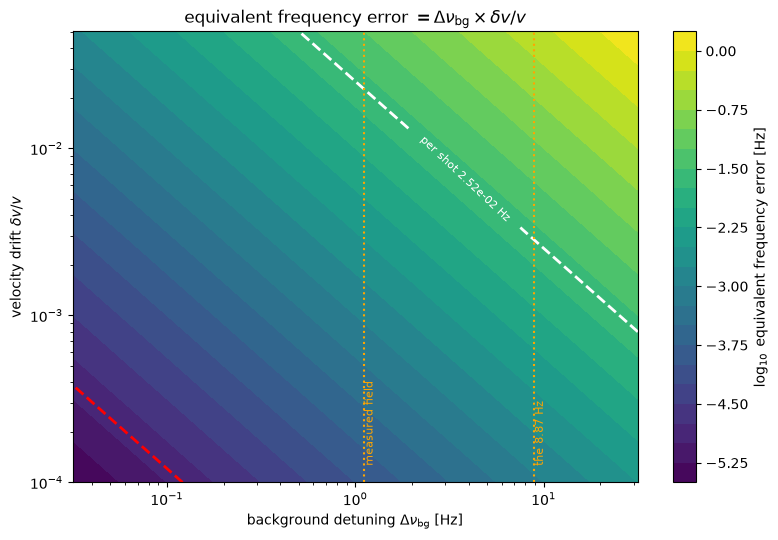

Below-left of a dashed line the noise is under the statistical limit.

  to stay under per shot at dv/v=1.0%: Delta_nu_bg < 2.519e+00 Hz (DC B_par < 1.013e+00 mG)
  to stay under per shot at dv/v=0.1%: Delta_nu_bg < 2.519e+01 Hz (DC B_par < 1.013e+01 mG)
  to stay under per day at dv/v=1.0%: Delta_nu_bg < 1.212e-03 Hz (DC B_par < 4.874e-04 mG)
  to stay under per day at dv/v=0.1%: Delta_nu_bg < 1.212e-02 Hz (DC B_par < 4.874e-03 mG)


In [114]:
# 5.3 Joint map, against the statistical sensitivity. Uses the analytic transfer function
# (validated in 5.1/5.2).
bg_grid  = np.logspace(-1.5, 1.5, 60)      # background detuning, Hz
eps_grid = np.logspace(-4, -1.3, 60)       # dv/v
BG, EE = np.meshgrid(bg_grid, eps_grid, indexing="ij")
dnu_map = np.abs(BG*EE)

fig, ax = plt.subplots(figsize=(8, 5.5))
cs = ax.contourf(BG, EE, np.log10(dnu_map), levels=25, cmap="viridis")
plt.colorbar(cs, ax=ax).set_label(r"$\log_{10}$ equivalent frequency error [Hz]")
for lvl, nm, col in [(S['per_shot'], f"per shot {S['per_shot']:.2e} Hz", "w"),
                     (S['per_day'],  f"per day {S['per_day']:.2e} Hz",  "r")]:
    c = ax.contour(BG, EE, dnu_map, levels=[lvl], colors=col, linewidths=2, linestyles="--")
    ax.clabel(c, fmt={lvl: nm}, fontsize=8)
for v, nm in [(abs(dnu_dBpar*CONFIG.B_par_G + DNU_TRANSVERSE), "measured field"),
              (8.87, "the 8.87 Hz")]:
    ax.axvline(v, color="orange", ls=":", lw=1.5)
    ax.text(v, eps_grid[2], f" {nm}", rotation=90, fontsize=8, color="orange")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"background detuning $\Delta\nu_{\rm bg}$ [Hz]")
ax.set_ylabel(r"velocity drift $\delta v/v$")
ax.set_title(r"equivalent frequency error $=\Delta\nu_{\rm bg}\times\delta v/v$")
plt.tight_layout(); plt.show()

print("Below-left of a dashed line the noise is under the statistical limit.\n")
for nm, S_t in [("per shot", S['per_shot']), ("per day", S['per_day'])]:
    for eps in (0.01, 0.001):
        print(f"  to stay under {nm} at dv/v={eps:.1%}: Delta_nu_bg < {S_t/eps:.3e} Hz "
              f"(DC B_par < {S_t/eps/abs(dnu_dBpar)*1e3:.3e} mG)")


In [115]:
# 5.4 Reversal-correlated systematics -- the channel that does not average down.
print("Reversal-correlated B_par requirement:")
for nm, S_t in [("per shot", S['per_shot']), ("per day", S['per_day'])]:
    B_req = S_t/abs(dnu_dBpar)
    print(f"  under {nm} ({S_t:.3e} Hz): |B_par(E-correlated)| < "
          f"{B_req*1e3:.3e} mG = {B_req*1e9:.3f} nG")

print(f"\nE-reversal amplitude reproducibility (dnu/dE = {COEF['dnu_dE']:.5f} Hz/(V/cm)):")
for nm, S_t in [("per shot", S['per_shot']), ("per day", S['per_day'])]:
    dE_req = S_t/abs(COEF['dnu_dE'])
    print(f"  under {nm}: |Delta E| < {dE_req:.3e} V/cm "
          f"= {dE_req/(CONFIG.E_plateau*1e3):.3e} relative")

print("\nBoth requirements are severe, which is the case for an internal comagnetometer:")
print("the two 119.51 kHz pairs share the Zeeman sign but have opposite dnu/dE, so their")
print("sum cancels E sensitivity and their difference cancels Zeeman. Open question: does")
print("the Schiff term add or cancel in the combination that cancels E sensitivity? (§6)")


Reversal-correlated B_par requirement:
  under per shot (2.519e-02 Hz): |B_par(E-correlated)| < 1.013e-02 mG = 10130.056 nG
  under per day (1.212e-05 Hz): |B_par(E-correlated)| < 4.874e-06 mG = 4.874 nG

E-reversal amplitude reproducibility (dnu/dE = -0.03178 Hz/(V/cm)):
  under per shot: |Delta E| < 7.926e-01 V/cm = 2.667e-05 relative
  under per day: |Delta E| < 3.813e-04 V/cm = 1.283e-08 relative

Both requirements are severe, which is the case for an internal comagnetometer:
the two 119.51 kHz pairs share the Zeeman sign but have opposite dnu/dE, so their
sum cancels E sensitivity and their difference cancels Zeeman. Open question: does
the Schiff term add or cancel in the combination that cancels E sensitivity? (§6)


## 5.5 Monte Carlo skeleton

The analytic transfer functions above suffice for a given DC value or a given ε. Real noise
has time structure: shot-to-shot vs slow drift, correlation time relative to the 11 ms
flight time, and correlation time relative to the reversal period (which decides whether it
lands in the noise channel or the systematic channel).

Skeleton below; **not executed** — the parameters are still placeholders.

In [116]:
def generate_ou_series(n, sigma, tau_corr, dt, rng):
    """Ornstein-Uhlenbeck (exponentially correlated) noise, a placeholder model.
    tau_corr -> 0: white (shot-to-shot independent).  tau_corr -> inf: DC offset."""
    if tau_corr <= 0:
        return rng.normal(0, sigma, n)
    a = np.exp(-dt/tau_corr)
    x = np.empty(n); x[0] = rng.normal(0, sigma)
    s = sigma*np.sqrt(1-a**2)
    for i in range(1, n):
        x[i] = a*x[i-1] + rng.normal(0, s)
    return x


def monte_carlo(cfg, coef, n_shots, B_sigma_G, B_tau_s, v_rel_sigma, v_tau_s,
                B_reversal_corr_G=0.0, seed=0, use_analytic=True):
    """use_analytic=True uses the transfer functions validated in 5.1/5.2 (fast).
    Reversal sequence simplified to shot-by-shot alternating E reversal.
    B_reversal_corr_G is the E-synchronous B_par component (systematic channel)."""
    rng = np.random.default_rng(seed)
    dt_shot = 1.0/(cfg.rep_rate_Hz*cfg.duty_cycle)
    B_n = generate_ou_series(n_shots, B_sigma_G, B_tau_s, dt_shot, rng)
    v_n = generate_ou_series(n_shots, v_rel_sigma, v_tau_s, dt_shot, rng)
    s_E = np.where(np.arange(n_shots) % 2 == 0, +1, -1)

    fm = FieldModel(cfg)
    sl = slope_dA_dnu(cfg, coef, fm)
    A_base, _, _ = readout_asymmetry(cfg, coef, fm)

    if use_analytic:
        B_tot = B_n + s_E*B_reversal_corr_G
        nu_bg = coef['dnu_dB'][2]*B_tot + cfg.nu_rf_offset_Hz
        dnu = coef['dnu_dB'][2]*B_tot + nu_bg*v_n + s_E*cfg.nu_schiff_Hz
        A = A_base + sl*dnu + rng.normal(0, 1/np.sqrt(cfg.N_per_shot), n_shots)
    else:
        A = np.empty(n_shots)
        for i in range(n_shots):
            cfg_i = Config(**{**cfg.__dict__, "v_z": cfg.v_z*(1+v_n[i])})
            Ai, _, _ = readout_asymmetry(cfg_i, coef, FieldModel(cfg_i),
                                         B_par=B_n[i] + s_E[i]*B_reversal_corr_G,
                                         schiff_sign=s_E[i])
            A[i] = Ai + rng.normal(0, 1/np.sqrt(cfg.N_per_shot))

    half_diff = 0.5*(A[s_E == +1].mean() - A[s_E == -1].mean())
    return dict(nu_extracted=half_diff/sl, nu_injected=cfg.nu_schiff_Hz,
                A=A, B=B_n, v=v_n)


print("Defined but NOT run. Input status:\n")
for nm, desc, have in [
        ("v_rel_sigma", f"relative v_z jitter -- HAVE: {CONFIG.v_shot_sigma}/184 "
                        f"= {CONFIG.v_shot_sigma/184:.4f} (shot-mean scatter)", True),
        ("v_tau_s", "correlation time of the v_z drift", False),
        ("B_sigma_G", "shot-to-shot jitter of B_par", False),
        ("B_tau_s", "correlation time of B_par", False),
        ("B_reversal_corr_G", "E-synchronous B_par component  <== most critical", False)]:
    print(f"  [{'x' if have else ' '}] {nm:<20} {desc}")
print("\n  [ ] reversal block structure. centrex_asymmetry uses randomized, balanced")
print("      eight-state blocks (make_three_switch_schedule); the skeleton here still")
print("      alternates shot by shot, which does not decorrelate slow drift.")
print("\n  Also not modelled: photon/detection noise inside the MC (the analytic")
print("  excess-noise factor F from §3 is applied, but not per-shot photon sampling),")
print("  and background light, which centrex_asymmetry also has not implemented.")


Defined but NOT run. Input status:

  [x] v_rel_sigma          relative v_z jitter -- HAVE: 4.0/184 = 0.0217 (shot-mean scatter)
  [ ] v_tau_s              correlation time of the v_z drift
  [ ] B_sigma_G            shot-to-shot jitter of B_par
  [ ] B_tau_s              correlation time of B_par
  [ ] B_reversal_corr_G    E-synchronous B_par component  <== most critical

  [ ] reversal block structure. centrex_asymmetry uses randomized, balanced
      eight-state blocks (make_three_switch_schedule); the skeleton here still
      alternates shot by shot, which does not decorrelate slow drift.

  Also not modelled: photon/detection noise inside the MC (the analytic
  excess-noise factor F from §3 is applied, but not per-shot photon sampling),
  and background light, which centrex_asymmetry also has not implemented.


---
# §6 Open inputs

## Answered by the COMSOL data

RF is a **magnetic** field (coils, M1, x polarization); spatial distribution is
`B_Ramsey_May6_FINAL_proc.csv` plus its mirror at 90°; peak 0.809 G × 0.365 = 0.295 G;
geometry is a 2 m domain with a 29.72 kV/cm plateau over x = 0.65–1.35 and
**0.394 m coil separation**; ∂ν/∂E and the coupling come from
`sib_split_vs_E.csv` / `Coupling.csv`, which agree with `centrex_tlf` to 0.6% and 1.3 ppm.

## Three inconsistencies to resolve

**1. The absolute transition frequency differs by 2.5 Hz** (1 mG equivalent). Emma's table
gives 119513.93 Hz at 30 kV/cm; `centrex_tlf` gives **two** pairs at 119511.4 and
119516.4 Hz, and Emma's value lands almost exactly midway. Candidate explanations, in
descending order of plausibility:
- her calculation does not distinguish the two pairs (single mF block, or an average);
- `AGENTS.md` warns the X Hamiltonian constants changed (a quartic `D_rot` term was added,
  `B_rot` moved ~24 kHz) and that **cached or pickled X Hamiltonians are stale** — a few Hz
  in J=1 is exactly the expected size. But the coupling agrees to 1.3 ppm, which argues
  against this;
- `PAIR_CHOICE` is wrong.

Ask Emma how `sib_split_vs_E.csv` was generated: which `centrex_tlf` version, whether a
cache was used, and the exact quantum numbers of "sibling".

**2. The +8.87 Hz offset in `detuning2.csv`.** Verified that
`detuning2(E) = −(|ν(E)| − |ν(30 kV/cm)|) + 8.87 Hz`, with the offset near-constant
(8.78…9.12) across 0–30 kV/cm. Intentional residual background detuning, or an artifact?
If real it is a larger v_z-drift amplifier than a 1 mG field (§5.2 case 3).

**3. Resolved.** `ramsey4matrix.py` had a wrong pair of B-field filenames and a
`pd.read_csv` header bug worth ~1% in `T_TOTAL`; both fixed in the working tree, and the two
codes now agree to 3.7e-15 (§4.1). Note it still runs the "everything off" configuration
(zero E, flat coupling, zero detuning) — deliberate, but worth switching on now that the
comparison is established.

**4. `FIELD_SCALE = 0.365` is a good π/2 setting, and there is a velocity-noise null
just above it.** On the phase-independent diagnostic (coil 2 off, so the relative phase
cannot interfere) the pulse area at 0.365 is **0.4855π**, i.e. 2.9% below π/2; exact π/2 is
at **0.37592**. Separately, the velocity-drift response has a **zero crossing at
FIELD_SCALE = 0.37844** — within 0.67% of the π/2 point. So trimming the RF amplitude by
about +3.5% should null the dominant technical noise channel (§5.2c).

Two earlier numbers in this notebook for the π/2 amplitude, 0.39866 and 0.31942, were
artifacts of a trajectory-midpoint criterion polluted by the frozen operating phase; the
coil-1-only diagnostic in §4.4 replaces them.

## Still missing, and blocking numbers

1. **N per shot, repetition rate, duty cycle for the small IR.** Without these only
   δν·√N is available. **Largest gap right now.** Note the photon budget is now partly
   pinned down — `centrex_asymmetry` gives pump-out 0.4823, 50 cycles, η = 0.052, so
   ~0.108 detected photons per molecule and an excess-noise factor F ≈ 3.2. Confirm those
   carry over to the small IR detector, and whether background light is expected (neither
   simulation models it).
2. **Is 0.394 m the final coil separation?** Sensitivity ∝ T_eff, so this sets the scale.
   Only 0.394 m of a 2 m tube is used — are the coil positions constrained by the E plateau
   (x = 0.65–1.35)?
3. **Magnetic field data, B∥E component only** (consequence a; verified numerically in
   §5.1), split into the three channels of §5: DC offset; shot-to-shot σ **and correlation
   time**; **E-synchronous component** (the only one that does not average down). If this
   lives in Jakob's `../magnetic shielding/6. Residual field.ipynb` /
   `25. Noise spectrum.ipynb`, say so and I will read it.
4. **Correlation time of the v_z drift.** The amplitude is now known — the shot-mean
   scatter is 4 m/s on 184, i.e. 2.2% per shot (`centrex_asymmetry` beam model) — but its
   correlation time, and how that compares to the reversal period, is not. That is what
   decides whether it lands in the noise channel or the systematic channel. Also: 180 m/s
   (Emma's script) or 184 m/s (design paper and `centrex_asymmetry`)?
5. **Reversal block structure.** The scheme itself is now settled (§3.5: d, p, c with
   Δf_sw = 0.5 Hz and φ_cal = π/32). What is missing is the *ordering* — how many shots per
   state, block length, and randomization. `centrex_asymmetry` uses randomized balanced
   eight-state blocks; §5.5 here still alternates shot by shot, which does not decorrelate
   slow drift. Also: is the small IR adding a B reversal, which neither simulation has?
6. **What `B2_PHASE = π/2` means** — fixed hardware quadrature, or the readout switch
   itself? Currently treated as the latter.
7. **The design paper's quoted statistical sensitivity**, for external validation.
8. **E-field file units and sign.** `E_Ramsey_May6_FINAL.csv` has a negative second column
   and a positive third (magnitude); the `_proc` version takes the positive one. Confirm
   `_proc` is the intended quantity.

## Suggestions

9. **Add the second 119.51 kHz pair for internal comagnetometry.** Same Zeeman sign,
   opposite ∂ν/∂E: the sum cancels E sensitivity, the difference cancels Zeeman. Nearly
   free — `candidates[1]` is already available. **But first settle whether the Schiff term
   adds or cancels in the E-cancelling combination**; if it cancels too, comagnetometry
   does not help. This is also tied to inconsistency 1: if Emma's model does not separate
   the two pairs, this option has not been considered yet.
10. **§4.3 is done: the pulse pull is +0.16 Hz at the operating amplitude, ≈1.8 Hz/G².**
    It cancels in the parity estimators as a common offset, so the actionable output is
    an **RF amplitude reproducibility requirement across reversals of ~4×10⁻⁵** to keep
    it under the one-day statistical limit. Worth asking what the actual coil-drive
    reproducibility is, and whether the E-field reversal perturbs the coil coupling at
    all — that is the route by which this becomes a systematic rather than an offset.
    Remaining numerical to-do: confirm convergence at N8 = 400k.

## Pitfalls inherited from `centrex_asymmetry`'s own review

Its README has a "Issues to Resolve Before Reuse" list. Three items are worth repeating
because they are easy to reproduce in any version of this simulation:

- **A partition of repetitions is not a physics reversal.** Its legacy analysis reshaped
  data into three binary switch axes while generation defined only two, so the third axis
  merely split repetitions. Contrast extracted that way is not a CP signal. §3.5 here
  generates all three switches explicitly.
- **Silent parameter dropping.** Its `experiment` accepted `bg1, bg2` but never forwarded
  them, so saved CSVs recorded nonzero background that was never injected. Worth a
  deliberate check whenever a parameter is threaded through several layers.
- **Match absolute arrival bins across switch states**, not row indices — dynamic per-shot
  time ranges otherwise misalign the states being differenced.

## Runnable now

§0 through §4.2 and §5.1–5.4 — fields and molecular structure are all in place. §3.5's
closure test is the strongest end-to-end check available and is cheap; run it early. Only
the absolute sensitivity (needs N) and §5.5 (needs the drift correlation time and block
structure) are blocked. §4.3 runs but is slow; run it separately and watch step-count
convergence.
